# Sequence Retrieval in a Kuramoto Dense Associative Memory

Results summary. Every experiment is reproduced from `hetero_rules_run.ipynb` (branching) and
`robustness_sweep.ipynb` (single chains); trial counts are set in **Configuration**.

## Contents

| § | question | key result |
|---|---|---|
| [0](#0) | What is the model? | Krotov DAM $\to$ Kuramoto, and the gate |
| [1](#1) | Why does anything move? | $\omega = 0$ is an exact fixed point; usable band $[0.02,\,0.2]$ |
| [2](#2) | Why is branching hard? | shared runs are bit-identical; the gate must reach past them |
| [3](#3) | Which rule wins? | reach $\ge L$ predicts branch choice; nothing clears $L = 3$ |
| [4](#4) | Does it hold up? | improves with $N$; non-monotone in $\rho$ |
| [5](#5) | Appendix | random patterns, settle-vs-loop, integration time |

**Metrics are defined twice, deliberately.** §3 covers the crossover metrics, §4 the
single-chain ones. They are not interchangeable, and each section lists how its own mislead.

<a id="0"></a>
## 0. Krotov DAM, and Kuramoto

**Dense memory.** Classical Hopfield stores $\sim 0.14N$ patterns because its energy is
quadratic in the overlaps. Krotov and Hopfield replace that with a sharp separation function,
$E = -\sum_\mu F(\sum_i \xi^\mu_i \sigma_i)$; with $F(x) = x^d$ capacity grows as
$P_{\max} \sim N^{\,d-1}$. Sharper $F$ $\Rightarrow$ the nearest pattern dominates the sum.

**Kuramoto.** Units are phases $\theta_i$, a stored pattern is a configuration on the
$\{0,\pi\}$ lattice, and the overlap is $m_\mu = \frac1N \sum_i \xi^\mu_i \cos\theta_i$.

**The map.** Retrieval is heteroassociative -- the drive built from the *current* pattern points
at the *next*, so the network walks a sequence instead of settling into it:

$$\dot\theta_i = \omega_i - \sin\theta_i \, V_i, \qquad
  V_i = \sum_{\mu} \xi^{\,\mu+1}_i \underbrace{m_{\mu}^{\,d}}_{\text{gate}}$$

The gate asks *"does the state look like $\xi^\mu$?"*; $\xi^{\mu+1}_i$ answers *"then go to
$\xi^{\mu+1}$"*. **Every rule in this notebook is a change to what the gate reads.**

Two consequences, both load-bearing:

1. The drive depends on $\sin\theta_i$ and $\cos\theta_j$ *absolutely*, not on phase
   differences. A uniform $\omega$ is **not** removable by a rotating frame -- it is a real
   parameter (§1).
2. At an exact cue all $\theta_i \in \{0,\pi\}$, so $\sin\theta_i = 0$ and $V_i$ moves nothing.
   The cue is an exact fixed point unless $\omega \neq 0$ (§1).

---

## Configuration

One config for the whole notebook, matching `hetero_rules_run.ipynb`: quenched disorder
$\omega_i \sim \mathcal{N}(0, 0.3)$, $d = 3$, $\rho = 0.2$, `tolerance` 0.5, `mode="ode"` (so
`phase_noise` is inert and every run is a deterministic ODE).

`TRIALS`, `SEED_TRIALS` and `SINGLE_SEQ_TRIALS` are the only knobs that trade runtime for
error bars. Every `ContextNetwork` is built with `seed=10`, so the $\omega$ draw is fixed and
never resampled -- **on the $\omega$ axis every result below is $n = 1$.**

In [1]:
%matplotlib inline

import itertools
from collections import Counter
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

root_dir = Path.cwd().parent.parent if Path.cwd().name == "hetero_learning" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import kuramoto.kuramoto_library as krm
import kuramoto.hetero_learning.kuramoto_hetero as kc

CONFIG = dict(dt=0.05, T=30.0, frequency_std=0.3, phase_noise=0.01, d=3,
              corruption_rate=0.2, tolerance=0.5, mode="ode")

# Two base sizes, matching the two source notebooks. Crossover branch choice improves
# sharply with N and saturates at 200 (hetero_rules_run.ipynb §11), so the branching
# experiments run there. The single-chain robustness sweeps keep N = 100 as their base and
# sweep N explicitly, which is the experiment.
N          = 100     # single-chain base (§4); N is a swept axis there
N_CROSS    = 200     # crossover experiments (§2, §3) -- the measured operating point
TRIALS     = 20      # crossover trials per rule; each runs 2 cueing attempts
SEED_TRIALS = 100    # the big seed sweep in §3
SINGLE_SEQ_TRIALS = 60
MARGIN     = 0.01    # crossover decoder hysteresis
SEQ_MARGIN = 0.001   # long-chain decoder hysteresis (neighbouring overlaps are ~0.003 apart)
SEED_POOL  = 10_000

SEQ_LEN = 9                      # 10 stored patterns on the long chain (§4)
DWELL_PER_TRANSITION = 20.0      # long-chain integration time = DWELL * seq_len

assert CONFIG["frequency_std"] > 0
print(f"N={N}  d={CONFIG['d']}  rho={CONFIG['corruption_rate']}  "
      f"sigma_omega={CONFIG['frequency_std']}  tolerance={CONFIG['tolerance']}")

N=100  d=3  rho=0.2  sigma_omega=0.3  tolerance=0.5


### Borrowed definitions

Verbatim from the two source notebooks -- the rule catalogue, the crossover machinery and the
single-sequence scorer. Nothing new is defined here; see those notebooks for the derivations.

In [2]:
RAW_CATALOGUE = {
    "self":          kc.self_rule(),
    "forward":       kc.forward_rule(),
    "skip-two":      kc.skip_rule(nhop=2),
    "self+forward":  kc.mixture(kc.self_rule(weight=0.3), kc.forward_rule(weight=1.0)),
    "forward+skip2": kc.mixture(kc.forward_rule(weight=1.0), kc.skip_rule(2, weight=0.5)),
    "bigram":        kc.bigram_rule(),
    "multilag":      kc.multilag_rule((1.0, 1.0, 1.0)),
    "coh bigram":    kc.coherent_bigram_rule(),
    "coh trigram":   kc.coherent_trigram_rule(),
}

# The gain step, applied here at the configured rate so every experiment below can compare
# a rule's raw and gain-corrected behavior directly.
GAIN_CATALOGUE = {name: kc.proportional_gain(rule, CONFIG["corruption_rate"])
                  for name, rule in RAW_CATALOGUE.items()}

print(f"{'rule':<15}{'target s':>9}{'lags':>12}{'raw w':>10}{'gain w':>10}")
print("-" * 56)
for name, rule in RAW_CATALOGUE.items():
    gain_rule = GAIN_CATALOGUE[name]
    for r, row in enumerate(rule):
        lags = ",".join(f"{int(l)}" for l in row[1:-1])
        print(f"{name if r == 0 else '':<15}{int(row[0]):>9}{'(' + lags + ')':>12}"
              f"{row[-1]:>10.3f}{gain_rule[r, -1]:>10.3f}")

rule            target s        lags     raw w    gain w
--------------------------------------------------------
self                   0     (0,0,0)     1.000     1.000
forward                1     (0,0,0)     1.000     1.000
skip-two               2     (0,0,0)     1.000     1.000
self+forward           0     (0,0,0)     0.300     0.231
                       1     (0,0,0)     1.000     0.769
forward+skip2          1     (0,0,0)     1.000     0.667
                       2     (0,0,0)     0.500     0.333
bigram                 1     (0,1,1)     1.000     2.778
multilag               1     (0,0,0)     1.000     0.333
                       1     (0,1,1)     1.000     0.926
                       1     (0,2,2)     1.000     2.572
coh bigram             1     (0,0,1)     1.000     1.667
coh trigram            1     (0,1,2)     1.000     4.630


In [3]:
def make_crossover_pair(N, corruption_rate, origin_seed, mutation_seeds,
                        seq_len, shared_idx):
    """The two sequences "A" and "B", `seq_len` patterns each, sharing a contiguous run at
    `shared_idx`. Two branches exactly -- every scorer below is written for a pair.

    Built as a mutation chain rather than a star around one origin, so consecutive patterns
    stay close enough for the dynamics to traverse. Both branches hold the same array object
    across the run, so those overlaps are bit-identical and the ambiguity is exact."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):                            # backwards off the front
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):              # forwards off the back
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


def classify_unshared(retrieved, multi, name, shared_idx):
    """METRIC 1 -- outcome of one cueing attempt, on the strict criterion: every unshared
    pattern of the cued sequence must come back, in order.

    correct    = all unshared positions decoded, in order, on the cued branch
    crossed    = the other branch showed up at an unshared position first
    incomplete = the path ran out before all of them appeared"""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)

    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"


def overlap_quality(overlaps, labels, name, seq_len, shared_idx):
    """METRIC 2 -- mean, over the cued branch's UNSHARED patterns, of each pattern's peak
    overlap. Only meaningful for an attempt classified "correct"; callers must check that
    separately. Shared positions are excluded because both branches store the identical
    array there, so they carry no rule-discriminating information."""
    shared = set(shared_idx)
    own_unshared = [labels.index((name, k)) for k in range(seq_len) if k not in shared]
    return float(overlaps[:, own_unshared].max(axis=0).mean())

In [4]:
# The benchmark topologies, one place. Every experiment below indexes this by tag.
GEOMETRIES = {
    "2-1-2": dict(seq_len=5, shared_idx=(2,),      duration=80.0),    # (a) eq (7)
    "2-2-2": dict(seq_len=6, shared_idx=(2, 3),    duration=80.0),    # (c) eq (9)
    "2-3-2": dict(seq_len=7, shared_idx=(2, 3, 4), duration=80.0),    # the failure case
    "1-1-1": dict(seq_len=3, shared_idx=(1,),      duration=60.0),    # legacy
}

# The write-up's benchmarks plus the failure case; the knobs and the seed sweep run on this
# subset rather than on the legacy geometry as well.
SPEC = ["2-1-2", "2-2-2", "2-3-2"]
FOCUS = ["2-1-2", "2-2-2", "2-3-2"]

for tag, g in GEOMETRIES.items():
    lo, hi = min(g["shared_idx"]), max(g["shared_idx"])
    print(f"{tag:<8} P={g['seq_len']}  shared={set(g['shared_idx'])}  "
          f"L={hi - lo + 1}  unshared before={lo}, after={g['seq_len'] - 1 - hi}  "
          f"duration={g['duration']:g}")


def run_crossover_trial(net, rng, seq_len, shared_idx, duration, corruption_rate=None):
    """One crossover instance, cued once from each sequence's first pattern.

    corruption_rate: defaults to CONFIG's; the seed sweep passes a per-trial draw."""
    rate = CONFIG["corruption_rate"] if corruption_rate is None else corruption_rate
    origin_seed = int(rng.integers(SEED_POOL))
    # 12 is an upper bound over the geometries (2-3-2 consumes 10), held fixed so the
    # draw sequence is identical at every geometry.
    mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
    multi = make_crossover_pair(N, rate, origin_seed, mutation_seeds, seq_len, shared_idx)
    labels = multi.labels()
    hi = max(shared_idx)

    out = {}
    for name in ("A", "B"):
        other = "B" if name == "A" else "A"
        result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
        outcome = classify_unshared(retrieved, multi, name, shared_idx)

        overlaps = net.overlaps(result["theta_history"], multi)
        own_peak   = overlaps[:, labels.index((name, hi + 1))].max()
        other_peak = overlaps[:, labels.index((other, hi + 1))].max()

        out[name] = dict(result=result, retrieved=retrieved, outcome=outcome,
                         branch_correct=bool(own_peak > other_peak),
                         margin=float(own_peak - other_peak),
                         overlap_quality=(overlap_quality(overlaps, labels, name, seq_len, shared_idx)
                                          if outcome == "correct" else None),
                         # the cued branch's own peak overlap at each position, in stored
                         # order -- the succession of retrieved peaks of section 9
                         peaks=[overlaps[:, labels.index((name, k))].max()
                                for k in range(seq_len)])
    return multi, out


def rule_sweep(catalogue, seq_len, shared_idx, duration, trials=TRIALS, seed=0,
               verbose=True, config_overrides=None, rate_sampler=None):
    """The sweep over whatever catalogue it is handed. Every rule gets a freshly seeded
    `default_rng(seed)`, so all of them see the same crossover instances.

    Returns, per rule, all four metrics: the `correct`/`crossed`/`incomplete` counter
    (metric 1), `mean_overlap` + `overlap_var` over the successful attempts only (metric 2),
    `branch_correct` (metric 3) and `margin` (metric 4).

    config_overrides: dict merged over CONFIG for this call (e.g. frequency_mean /
    frequency_std) -- used by the constant-omega section.
    rate_sampler: called as rate_sampler(rng) once per trial to draw that trial's
    corruption rate; None keeps CONFIG's fixed rate -- used by the seed sweep."""
    net_config = {**CONFIG, **(config_overrides or {})}
    stats, first = {}, {}
    for rule, table in catalogue.items():
        net = kc.ContextNetwork(rule=table, N=N, seed=10, **net_config)
        rng = np.random.default_rng(seed)
        counter, branch_vals, margins, qualities = Counter(), [], [], []
        peaks, rates = [], []
        for trial in range(trials):
            rate = rate_sampler(rng) if rate_sampler is not None else None
            if rate is not None:
                rates.append(rate)
            multi, out = run_crossover_trial(net, rng, seq_len, shared_idx, duration,
                                            corruption_rate=rate)
            if trial == 0:
                first[rule] = (net, multi, out)
            for name in ("A", "B"):
                counter[out[name]["outcome"]] += 1
                branch_vals.append(float(out[name]["branch_correct"]))
                margins.append(out[name]["margin"])
                peaks.append(out[name]["peaks"])
                if out[name]["overlap_quality"] is not None:
                    qualities.append(out[name]["overlap_quality"])
        attempts = sum(counter.values())
        # Branch choice is the quantity these benchmarks exist to measure, so it is reported
        # with a spread like every other metric. It is a proportion over Bernoulli attempts, so
        # its error bar is the binomial standard error sqrt(p(1-p)/n) -- the s.d. of the
        # attempts themselves is a function of p and carries no extra information. `margin` is
        # the continuous quantity underneath it and does get a genuine s.d.
        p_branch = float(np.mean(branch_vals))
        stats[rule] = dict(counter=counter, attempts=attempts,
                           branch_correct=p_branch,
                           branch_se=float(np.sqrt(p_branch * (1 - p_branch) / attempts)),
                           branch_vals=np.asarray(branch_vals),
                           margin=float(np.mean(margins)), margin_std=float(np.std(margins)),
                           mean_overlap=float(np.mean(qualities)) if qualities else float("nan"),
                           overlap_var=float(np.var(qualities)) if qualities else float("nan"),
                           peaks=np.asarray(peaks), rates=rates)
        if verbose:
            q = stats[rule]["mean_overlap"]
            q_str = f"{q:+.3f}" if q == q else "  n/a"
            print(f"{rule:<15} correct={counter['correct'] / attempts:>5.0%}  "
                  f"crossed={counter['crossed'] / attempts:>5.0%}  "
                  f"incomplete={counter['incomplete'] / attempts:>5.0%}   "
                  f"overlap={q_str}   "
                  f"branch-correct={p_branch:>5.0%} +/-{stats[rule]['branch_se']:<5.3f}"
                  f"  margin={np.mean(margins):>+6.3f} +/-{np.std(margins):.3f}")
    return stats, first


kinds = ["correct", "crossed", "incomplete"]


def zeroed(values):
    """nan -> 0.0. `mean_overlap` is nan when a rule had no successful attempt to average;
    plotting nan leaves a gap and the line or bar simply vanishes. A rule that never
    retrieves anything should read as a flat zero, which is what it scored."""
    return [0.0 if v != v else float(v) for v in values]


def plot_rule_stats(stats, title, axes=None, show_overlap_var=False):
    """Three panels, one per reported metric family.

    Left   -- metric 1, each outcome count divided by the number of cueing attempts, so the
              bar is a fraction in [0, 1] and `correct` is read against a fixed ceiling
              rather than against the other rules.
    Middle -- metric 2, overlap quality on the successful attempts only (error bars =
              1 standard deviation across those attempts, when `show_overlap_var`).
    Right  -- metric 3, the branch-choice diagnostic, which the outcome bar cannot show.
              Chance is 0.5."""
    names = list(stats)
    attempts = stats[names[0]]["attempts"]
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 4.4))
    axes = np.atleast_1d(axes)      # a single-row subplots() call hands back a bare Axes

    bottom = np.zeros(len(names))
    for kind in kinds:
        heights = np.array([stats[n]["counter"][kind] / attempts for n in names])
        axes[0].bar(names, heights, bottom=bottom, label=kind)
        bottom += heights
    axes[0].set_ylabel("fraction of cueing attempts")
    axes[0].set_ylim(0, 1.0)
    axes[0].set_title(f"{title} -- strict full retrieval  ({attempts} attempts per rule)")
    axes[0].legend(fontsize=8)

    quality = [stats[n]["mean_overlap"] for n in names]
    err = ([np.sqrt(stats[n]["overlap_var"]) if stats[n]["overlap_var"] == stats[n]["overlap_var"] else 0.0
            for n in names] if show_overlap_var else None)
    bars = axes[1].bar(names, zeroed(quality), yerr=err, capsize=3, color="tab:green")
    for bar, v in zip(bars, quality):
        if v != v:
            axes[1].text(bar.get_x() + bar.get_width() / 2, 0.02, "0 (none correct)",
                         ha="center", va="bottom", fontsize=7, rotation=90, color="tab:red")
    axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
    axes[1].set_ylabel("mean peak overlap (successful attempts only)")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"{title} -- overlap quality")
    axes[1].legend(fontsize=8)

    axes[2].bar(names, [stats[n]["branch_correct"] for n in names], color="tab:purple")
    axes[2].axhline(0.5, color="k", ls="--", lw=1, label="chance")
    axes[2].set_ylabel("fraction branch-correct")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title(f"{title} -- branch choice at the shared state")
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
    return axes


2-1-2    P=5  shared={2}  L=1  unshared before=2, after=2  duration=80
2-2-2    P=6  shared={2, 3}  L=2  unshared before=2, after=2  duration=80
2-3-2    P=7  shared={2, 3, 4}  L=3  unshared before=2, after=2  duration=80
1-1-1    P=3  shared={1}  L=1  unshared before=1, after=1  duration=60


In [5]:
def mean_overlap_score(result, seq):
    """METRIC 2 -- mean, over every non-cue pattern in `seq`, of that pattern's PEAK overlap,
    from an already-computed simulate() result. Only meaningful for a correctly retrieved
    trial -- callers must check that separately (see single_sequence_score_sweep)."""
    return float(result["overlaps"][:, 1:].max(axis=0).mean())


def zeroed(values):
    """nan -> 0.0.  `mean_overlap` is nan when a rule had no successful trial to average;
    plotting nan leaves a gap and the line ends abruptly mid-axis. A rule that never
    retrieves anything should read as a flat zero, which is what it scored."""
    return [0.0 if v != v else float(v) for v in values]


def band(ax, x, means, stds, **kw):
    """Draw metric 2 as a line with a +/- 1 standard-deviation band -- the spread of overlap
    quality across the successful trials."""
    means, stds = np.asarray(zeroed(means)), np.asarray(zeroed(stds))
    line, = ax.plot(x, means, "-o", **kw)
    ax.fill_between(x, means - stds, means + stds, color=line.get_color(), alpha=0.12, lw=0)
    return line


def generate_random_sequence(N, seq_len, name, seed):
    """A sequence of seq_len+1 INDEPENDENTLY random patterns -- no mutation chain, unlike
    generate_sequence, so consecutive patterns are unrelated rather than similar."""
    rng = np.random.default_rng(seed)
    patterns = [rng.choice([0.0, np.pi], size=N) for _ in range(seq_len + 1)]
    return krm.sequence_from_patterns(name, patterns)


def displaced_cue(seq, corruption_rate, phase_jitter, rng):
    """theta(0) for the omega = 0 runs: a displacement of the zeroth stored pattern.

    The displacement is NOT a stored pattern -- it is never added to `seq` and never
    memorised, it is only where the trajectory starts. Two parts:

      - `corruption_rate` neurons flipped 0 <-> pi, the same corruption operator the
        mutation chain is built from;
      - `phase_jitter`, a small uniform angular nudge on every neuron.

    The jitter is what makes the displacement effective. `corrupt_phase` keeps every phase
    on the {0, pi} lattice, where sin(theta) = 0 exactly -- so at omega = 0 the drive
    vanishes identically and a flip-only displacement is still an exact fixed point. The
    angular nudge takes theta off the lattice so sin(theta) != 0 and the dynamics can run."""
    theta = krm.corrupt_phase(seq[0], corruption_rate, rng)
    if phase_jitter > 0:
        theta = theta + rng.uniform(-phase_jitter, phase_jitter, size=theta.shape[0])
    return theta


def run_single_trial(net, seq, duration, boundary=None, cue_corruption_rate=0.0,
                     cue_phase_jitter=0.0, rng=None):
    """One integration, returning a simulate()-shaped result dict.

    With no displacement this is just `net.simulate`. With one, the cue is built by
    `displaced_cue` and handed to `net._integrate` directly, since `net.simulate` always
    constructs an exact, uncorrupted cue."""
    if cue_corruption_rate > 0 or cue_phase_jitter > 0:
        theta_init = displaced_cue(seq, cue_corruption_rate, cue_phase_jitter, rng)
        theta_history, time = net._integrate(seq, theta_init, None, None, duration, boundary)
        return {"time": time, "theta_history": theta_history, "cue": (seq.name, 0),
                "overlaps": net.overlaps(theta_history, seq)}
    return net.simulate(seq, T=duration, boundary=boundary)


def single_sequence_score_sweep(catalogue, seq_len, corruption_rate, N, trials=SINGLE_SEQ_TRIALS,
                                seed=0, boundary=None, config_overrides=None,
                                cue_corruption_rate=0.0, cue_phase_jitter=0.0,
                                random_patterns=False, duration=None):
    """For each rule, run `trials` freshly generated single sequences of size `N` and report:
      - retrieval_fraction / fraction_std: METRIC 1, the mean over trials of
        `compare_to_stored_sequence(retrieved, seq) / len(seq)` -- the share of the sequence
        recovered, in order, before the first failure. Partial credit; 1.0 means full recall.
        The spread is over trials, i.e. across generated chains -- it says whether a rule is
        uniformly mediocre or bimodal (some chains fully recalled, others dropped early).
      - retrieval_rate: METRIC 2, the STRICT rate -- the fraction of trials scoring exactly
        1.0 on metric 1.
      - mean_overlap / overlap_std / overlap_var: METRIC 3, mean_overlap_score over ONLY the
        fully-retrieved trials, and its spread (nan if none -- plot via `zeroed`).
      - n_correct: how many trials the metric-3 statistics are averaged over.

    Decoded with `decode_sequence_online`: a pattern counts as retrieved only while it is
    the closest stored pattern to the state. A pattern whose own overlap peaks while some
    other pattern sits higher is a mixture dominated by that other pattern, not a retrieval.

    duration: integration time. Defaults to DWELL_PER_TRANSITION * seq_len, so a longer
        sequence gets proportionally longer to traverse and the sweep measures the rule
        rather than the clock.
    boundary: passed straight through (None/"self" settles at the last pattern, "cycle"
        loops back to the first) -- used by the settle-vs-loop test.
    config_overrides: dict merged over CONFIG for this call (e.g. frequency_mean/std) --
        used by the frequency-condition tests.
    cue_corruption_rate / cue_phase_jitter: start from a displacement of seq[0] instead of
        seq[0] itself -- see `displaced_cue`. Needed for the omega = 0 configuration.
    random_patterns: if True, use generate_random_sequence instead of generate_sequence --
        stored patterns are independent rather than a mutation chain (corruption_rate is
        then unused).
    """
    duration = DWELL_PER_TRANSITION * seq_len if duration is None else duration
    rng = np.random.default_rng(seed)
    net_config = {**CONFIG, **(config_overrides or {})}
    results = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **net_config)
        overlap_vals, fractions = [], []
        for _ in range(trials):
            if random_patterns:
                seq = generate_random_sequence(N, seq_len, name="A", seed=int(rng.integers(SEED_POOL)))
            else:
                seq = krm.generate_sequence(N, seq_len, corruption_rate, name="A",
                                            seed=int(rng.integers(SEED_POOL)))
            result = run_single_trial(net, seq, duration, boundary=boundary,
                                      cue_corruption_rate=cue_corruption_rate,
                                      cue_phase_jitter=cue_phase_jitter, rng=rng)
            retrieved = net.decode_sequence_online(result, seq, margin=SEQ_MARGIN)
            reached = net.compare_to_stored_sequence(retrieved, seq)
            fractions.append(reached / len(seq))
            if reached == len(seq):
                overlap_vals.append(mean_overlap_score(result, seq))
        results[name] = dict(
            retrieval_fraction=float(np.mean(fractions)),
            fraction_std=float(np.std(fractions)),
            retrieval_rate=len(overlap_vals) / trials,
            n_correct=len(overlap_vals),
            mean_overlap=float(np.mean(overlap_vals)) if overlap_vals else float("nan"),
            overlap_std=float(np.std(overlap_vals)) if overlap_vals else float("nan"),
            overlap_var=float(np.var(overlap_vals)) if overlap_vals else float("nan"),
        )
    return results

---
<a id="1"></a>
# 1. Why anything moves: the natural frequency

At an exact cue $\sin\theta_i = 0$, so the coupling $-\sin\theta_i V_i$ vanishes **identically**,
however large $V_i$ is. With $\omega \equiv 0$ the cue is an exact fixed point -- a degeneracy,
not a weak drive, so no rule or longer run can fix it. $\omega \neq 0$ rotates the state off the
lattice and the coupling can act.

- **(a)** $\omega \equiv 0$, exact cue -- frozen.
- **(b)** $\omega \equiv 0$, *displaced* cue (flips **plus** angular jitter, so the start is
  genuinely off-lattice) -- the dynamics run but **drift into a mixture** rather than ordering.
  Strict retrieval $0$–$15\%$ against $\ge 75\%$ once $\omega \neq 0$: the coupling alone
  occasionally carries a chain, but there is no reliable cascade.
- **(c)** $\sigma_\omega = 0.3$ -- a clean cascade, each pattern peaking in turn.

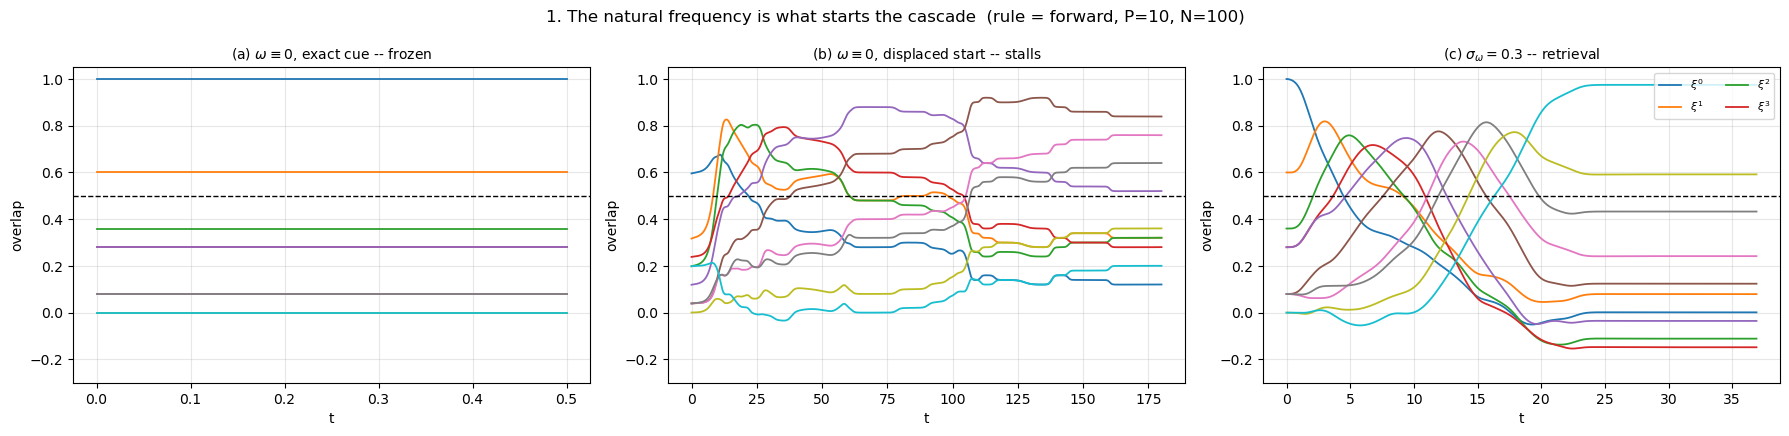

  (a) exact cue, w=0         integrated steps=   11   patterns recovered in order = 1/10
  (b) displaced, w=0         integrated steps= 3601   patterns recovered in order = 6/10
  (c) sigma_w=0.3            integrated steps=  739   patterns recovered in order = 10/10


In [6]:
DEMO_RULE = "forward"
demo_seq = krm.generate_sequence(N, SEQ_LEN, CONFIG["corruption_rate"], name="A", seed=1234)
demo_T = DWELL_PER_TRANSITION * SEQ_LEN

def overlap_panel(ax, result, seq, title):
    ov = result["overlaps"] if "overlaps" in result else None
    t = result["time"]
    for k in range(len(seq)):
        ax.plot(t, ov[:, k], lw=1.3, label=f"$\\xi^{{{k}}}$" if k < 4 else None)
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    ax.set_title(title, fontsize=10); ax.set_xlabel("t"); ax.set_ylabel("overlap")
    ax.set_ylim(-0.3, 1.05); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.4))

# (a) omega = 0, exact cue -- an exact fixed point
net0 = kc.ContextNetwork(rule=RAW_CATALOGUE[DEMO_RULE], N=N, seed=10,
                         **{**CONFIG, "frequency_mean": 0.0, "frequency_std": 0.0})
r_a = net0.simulate(demo_seq, T=demo_T)
overlap_panel(axes[0], r_a, demo_seq, r"(a) $\omega \equiv 0$, exact cue -- frozen")

# (b) omega = 0, displaced start -- moves, then stalls
rng = np.random.default_rng(0)
r_b = run_single_trial(net0, demo_seq, demo_T, cue_corruption_rate=CONFIG["corruption_rate"],
                       cue_phase_jitter=0.2, rng=rng)
overlap_panel(axes[1], r_b, demo_seq, r"(b) $\omega \equiv 0$, displaced start -- stalls")

# (c) the configured disorder -- a full cascade
net_d = kc.ContextNetwork(rule=RAW_CATALOGUE[DEMO_RULE], N=N, seed=10, **CONFIG)
r_c = net_d.simulate(demo_seq, T=demo_T)
overlap_panel(axes[2], r_c, demo_seq, rf"(c) $\sigma_\omega = {CONFIG['frequency_std']}$ -- retrieval")
axes[2].legend(fontsize=8, ncol=2, loc="upper right")
fig.suptitle(f"1. The natural frequency is what starts the cascade  (rule = {DEMO_RULE}, "
             f"P={SEQ_LEN + 1}, N={N})")
plt.tight_layout(); plt.show()

for tag, r in (("(a) exact cue, w=0", r_a), ("(b) displaced, w=0", r_b),
               (f"(c) sigma_w={CONFIG['frequency_std']}", r_c)):
    net_used = net0 if tag.startswith(("(a)", "(b)")) else net_d
    reached = net_used.compare_to_stored_sequence(
        net_used.decode_sequence_online(r, demo_seq, margin=SEQ_MARGIN), demo_seq)
    print(f"  {tag:<26} integrated steps={r['theta_history'].shape[0]:>5}   "
          f"patterns recovered in order = {reached}/{len(demo_seq)}")

## How much frequency? A ceiling, not a peak

Sweeping a constant $\omega$ ($\sigma_\omega = 0$, so only the magnitude changes) gives three
regions:

- **$\omega = 0$ is singular, not slow.** Exactly zero is a fixed point; any $\varepsilon > 0$ is
  a different regime.
- **A ceiling, not a peak.** Flat over $\approx [0.01, 0.3]$ at $T = 180$, decaying above, where
  the drift competes with the coupling holding each pattern.
- **The lower edge moves with duration.** At $T = 54$ the escape below $\omega \approx 0.01$
  outlasts the integration; at $T = 180$ that floor drops below the sweep. Only this end is
  duration-sensitive, so the band is a property of $(\omega, T)$ jointly, not of $\omega$ alone.

So $\omega$ breaks the degeneracy rather than pacing the cascade.

Unexplained, both visible below: **`multilag` is far more $\omega$-tolerant** than the rest, and
there is a **non-monotone dip near $\omega \approx 0.45$**.

Carried into §4: at matched magnitude a *constant* $\omega$ is uniformly **easier** than
disorder of the same width. The difficulty at $\sigma_\omega = 0.3$ is the spread, not the
magnitude.

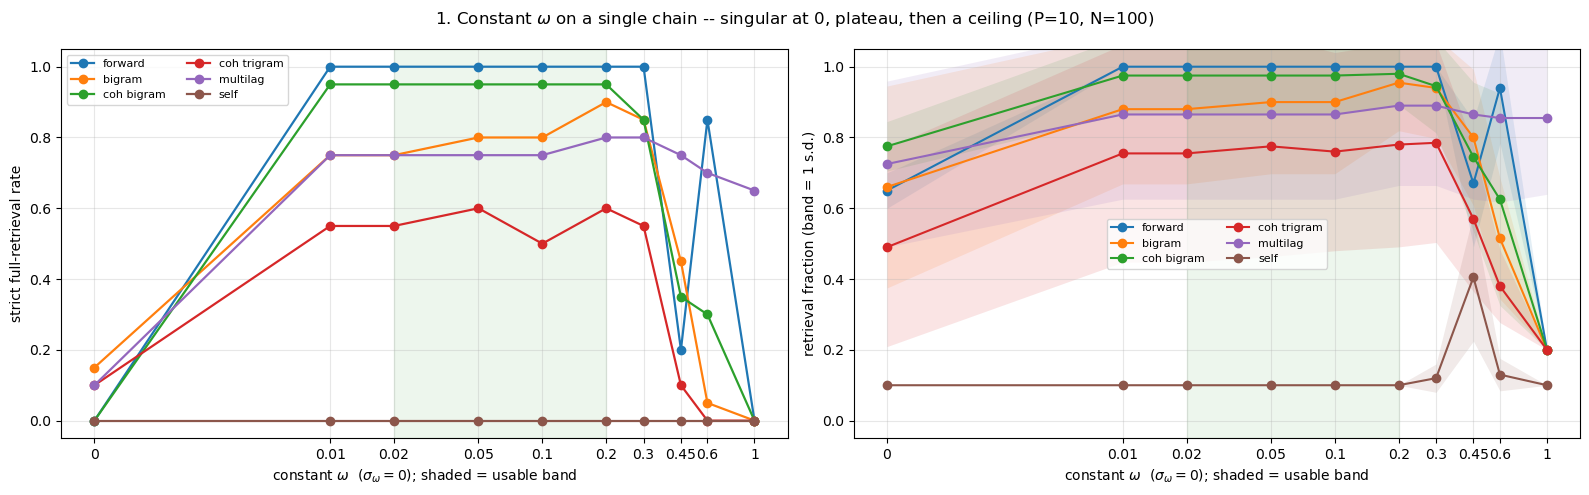

strict full-retrieval rate vs constant omega   (20 trials)
rule          0       0.01    0.02    0.05    0.1     0.2     0.3     0.45    0.6     1       
forward       0%      100%    100%    100%    100%    100%    100%    20%     85%     0%      
bigram        15%     75%     75%     80%     80%     90%     85%     45%     5%      0%      
coh bigram    0%      95%     95%     95%     95%     95%     85%     35%     30%     0%      
coh trigram   10%     55%     55%     60%     50%     60%     55%     10%     0%      0%      
multilag      10%     75%     75%     75%     75%     80%     80%     75%     70%     65%     
self          0%      0%      0%      0%      0%      0%      0%      0%      0%      0%      

omega = 0 uses a displaced start; every other column is cued exactly.


In [7]:
OMEGA_SWEEP = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.45, 0.6, 1.0]
OMEGA_SWEEP_RULES = ["forward", "bigram", "coh bigram", "coh trigram", "multilag", "self"]
OMEGA_SWEEP_TRIALS = 20

def strict_at_omega(rule, w, trials=OMEGA_SWEEP_TRIALS):
    """Long-chain scores at constant omega (frequency_std = 0). omega = 0 needs a displaced
    start -- an exact cue there is an exact fixed point and nothing would move."""
    kw = dict(cue_corruption_rate=CONFIG["corruption_rate"], cue_phase_jitter=0.2) if w == 0 else {}
    r = single_sequence_score_sweep({rule: RAW_CATALOGUE[rule]}, seq_len=SEQ_LEN,
                                    corruption_rate=CONFIG["corruption_rate"], N=N, trials=trials,
                                    config_overrides={"frequency_mean": w, "frequency_std": 0.0}, **kw)
    return r[rule]["retrieval_rate"], r[rule]["retrieval_fraction"], r[rule]["fraction_std"]

omega_curve = {r: [strict_at_omega(r, w) for w in OMEGA_SWEEP] for r in OMEGA_SWEEP_RULES}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.0))
for rule in OMEGA_SWEEP_RULES:
    axes[0].plot(OMEGA_SWEEP, [v[0] for v in omega_curve[rule]], "-o", lw=1.6, label=rule)
    band(axes[1], OMEGA_SWEEP, [v[1] for v in omega_curve[rule]],
         [v[2] for v in omega_curve[rule]], label=rule)
for ax, lab in zip(axes, ("strict full-retrieval rate", "retrieval fraction (band = 1 s.d.)")):
    ax.axvspan(0.02, 0.2, color="green", alpha=0.07)
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_xticks(OMEGA_SWEEP, [f"{w:g}" for w in OMEGA_SWEEP])
    ax.set_xlabel(r"constant $\omega$  ($\sigma_\omega = 0$); shaded = usable band")
    ax.set_ylabel(lab); ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
fig.suptitle(f"1. Constant $\\omega$ on a single chain -- singular at 0, plateau, then a ceiling "
             f"(P={SEQ_LEN + 1}, N={N})")
plt.tight_layout(); plt.show()

print(f"strict full-retrieval rate vs constant omega   ({OMEGA_SWEEP_TRIALS} trials)")
print(f"{'rule':<14}" + "".join(f"{w:<8g}" for w in OMEGA_SWEEP))
for rule in OMEGA_SWEEP_RULES:
    print(f"{rule:<14}" + "".join(f"{v[0]:<8.0%}" for v in omega_curve[rule]))
print("\nomega = 0 uses a displaced start; every other column is cued exactly.")

---
<a id="2"></a>
# 2. Why branching is hard, and what fixes it

The real problem is two sequences **sharing a run of patterns** and then diverging. At the branch
point the state sits on a pattern belonging to both.

**Why the basic rule cannot choose.** Its gate reads only the current pattern, $m_\mu^d$. Inside
a shared run that pattern is *bit-identical* between branches, so the gate is identical and the
drive points at both continuations equally. The outcome is left to residual asymmetry -- chance.

**The fix.** Let the gate also read lags $1, 2, \dots$. If **one factor lands outside the shared
run** it sees a pattern that differs between branches, and the product becomes branch-specific:

$$\text{gate} = m^{(1)}_{\mu} \cdot m^{(1)}_{\mu-1} \cdots \quad \text{(a "coherent" rule)}$$

A shared run of length $L$ needs reach $\ge L$ -- **necessary, not sufficient** (§3).

Below: one crossover, same instance in every panel, cued from $A[0]$. Solid = cued branch $A$,
dashed = $B$; shared positions excluded.

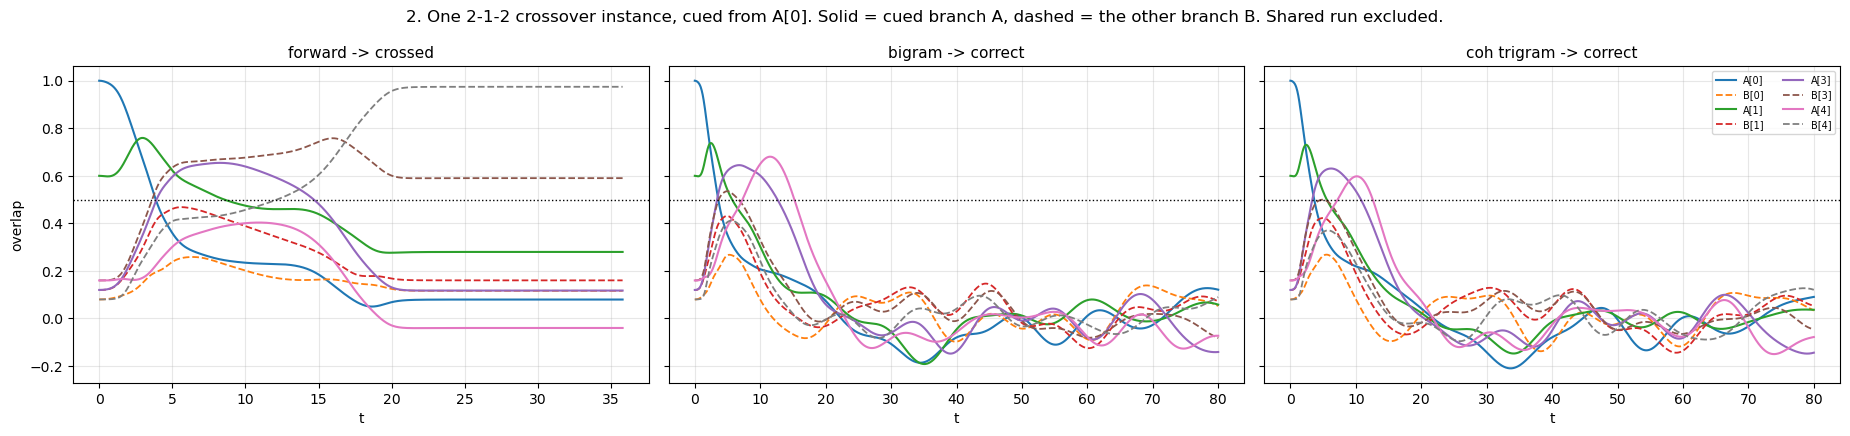

Reach needed on 2-1-2: L = 1
  self            max lag read by the gate =  0
  forward         max lag read by the gate =  0
  skip-two        max lag read by the gate =  0
  self+forward    max lag read by the gate =  0
  forward+skip2   max lag read by the gate =  0
  bigram          max lag read by the gate =  1
  multilag        max lag read by the gate =  2
  coh bigram      max lag read by the gate =  1
  coh trigram     max lag read by the gate =  2


In [8]:
DEMO_GEOM = "2-1-2"
DEMO_RULES = ["forward", "bigram", "coh trigram"]
g = GEOMETRIES[DEMO_GEOM]
shared = set(g["shared_idx"])

rng = np.random.default_rng(3)
multi = make_crossover_pair(N, CONFIG["corruption_rate"], int(rng.integers(SEED_POOL)),
                            rng.choice(SEED_POOL, size=12, replace=False).tolist(),
                            g["seq_len"], g["shared_idx"])
labels = multi.labels()

fig, axes = plt.subplots(1, len(DEMO_RULES), figsize=(6.2 * len(DEMO_RULES), 4.4), sharey=True)
for ax, rule in zip(np.atleast_1d(axes), DEMO_RULES):
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[rule], N=N, seed=10, **CONFIG)
    res = net.simulate(multi, cue=multi["A"], cue_idx=0, T=g["duration"])
    ov = net.overlaps(res["theta_history"], multi)
    for k in range(g["seq_len"]):
        if k in shared:
            continue
        ax.plot(res["time"], ov[:, labels.index(("A", k))], "-",  lw=1.5, label=f"A[{k}]")
        ax.plot(res["time"], ov[:, labels.index(("B", k))], "--", lw=1.3, label=f"B[{k}]")
    ax.axhline(CONFIG["tolerance"], color="k", ls=":", lw=1)
    retrieved = net.decode_sequence_online(res, multi, margin=MARGIN)
    outcome = classify_unshared(retrieved, multi, "A", g["shared_idx"])
    ax.set_title(f"{rule} -> {outcome}", fontsize=11)
    ax.set_xlabel("t"); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("overlap")
np.atleast_1d(axes)[-1].legend(fontsize=7, ncol=2)
fig.suptitle(f"2. One {DEMO_GEOM} crossover instance, cued from A[0]. "
             f"Solid = cued branch A, dashed = the other branch B. Shared run excluded.")
plt.tight_layout(); plt.show()

print(f"Reach needed on {DEMO_GEOM}: L = {max(g['shared_idx']) - min(g['shared_idx']) + 1}")
for rule, table in RAW_CATALOGUE.items():
    lags = np.atleast_2d(np.asarray(table, dtype=float))[:, 1:-1]
    print(f"  {rule:<15} max lag read by the gate = {int(lags.max()):>2}")

---
<a id="3"></a>
# 3. Metrics, topologies, and which rule wins

## The metrics

Each instance is cued **twice**, once per branch, so `TRIALS` trials give $2\times$`TRIALS`
attempts. Four scores per attempt:

| # | metric | definition |
|---|---|---|
| 1 | **outcome** | `correct` = every unshared pattern of the cued branch, **in order**, before the other branch appears. `crossed` = wrong branch first. `incomplete` = ran out. |
| 2 | **overlap quality** | mean peak overlap of those patterns, over **successful attempts only**, with spread |
| 3 | **branch-correct** | did the trajectory favour the right continuation? Chance = 0.5 |
| 4 | **margin** | signed gap between the cued and other continuation's peak overlap |

Shared positions are excluded throughout: both branches store the identical array there.

**Metric 3 is the one that matters.** It isolates the decision; metric 1 bundles it with
completion. Empirically

$$\text{correct} \;\approx\; \text{branch-correct} \times (1 - \text{incomplete})$$

to within $\sim$6%, so a low `correct` is always *two* failures multiplying. `correct` is also a
strict AND over $\sim$4 positions, so 0.87 per-position reads as 57%.

## The topologies

`before-shared-after`, all smooth mutation chains (consecutive patterns differ by $\rho N$ flips):

In [9]:
print(f"{'tag':<8}{'P':>3}{'shared':>10}{'L':>3}{'reach needed':>14}{'duration':>10}")
for tag, g in GEOMETRIES.items():
    lo, hi = min(g["shared_idx"]), max(g["shared_idx"])
    print(f"{tag:<8}{g['seq_len']:>3}{str(sorted(g['shared_idx'])):>10}{hi - lo + 1:>3}"
          f"{hi - lo + 1:>14}{g['duration']:>10g}")

tag       P    shared  L  reach needed  duration
2-1-2     5       [2]  1             1        80
2-2-2     6    [2, 3]  2             2        80
2-3-2     7 [2, 3, 4]  3             3        80
1-1-1     3       [1]  1             1        60


## The benchmark, raw and gain-corrected

`kc.proportional_gain` divides each term by $(1-2\rho)^{\sum \text{lags}}$, removing the
handicap a lag-heavy gate carries (its gate factors are each $< 1$, so a three-factor product
is small before it ever sees a branch). Both columns are run so the correction is *measured*,
not assumed.

In [10]:
_N_KEEP = N
N = N_CROSS          # crossover experiments run at the operating point
bench = {}
for tag in SPEC:
    for variant, cat in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE)):
        print("=" * 96); print(f"{tag}  --  {variant}")
        bench[(tag, variant)], _ = rule_sweep(cat, **GEOMETRIES[tag])
N = _N_KEEP


2-1-2  --  raw
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.005 +/-0.034
forward         correct=  52%  crossed=  48%  incomplete=   0%   overlap=+0.862   branch-correct=  55% +/-0.079  margin=+0.006 +/-0.090
skip-two        correct=   0%  crossed=  12%  incomplete=  88%   overlap=  n/a   branch-correct=  85% +/-0.056  margin=+0.096 +/-0.064
self+forward    correct=  15%  crossed=  18%  incomplete=  68%   overlap=+0.889   branch-correct=  55% +/-0.079  margin=-0.003 +/-0.068
forward+skip2   correct=  65%  crossed=  25%  incomplete=  10%   overlap=+0.865   branch-correct=  75% +/-0.068  margin=+0.060 +/-0.089
bigram          correct=  62%  crossed=   5%  incomplete=  32%   overlap=+0.774   branch-correct= 100% +/-0.000  margin=+0.124 +/-0.062
multilag        correct=  68%  crossed=  20%  incomplete=  12%   overlap=+0.891   branch-correct=  82% +/-0.060  margin=+0.099 +/-0.088
coh bigram      correct=  70%  cros

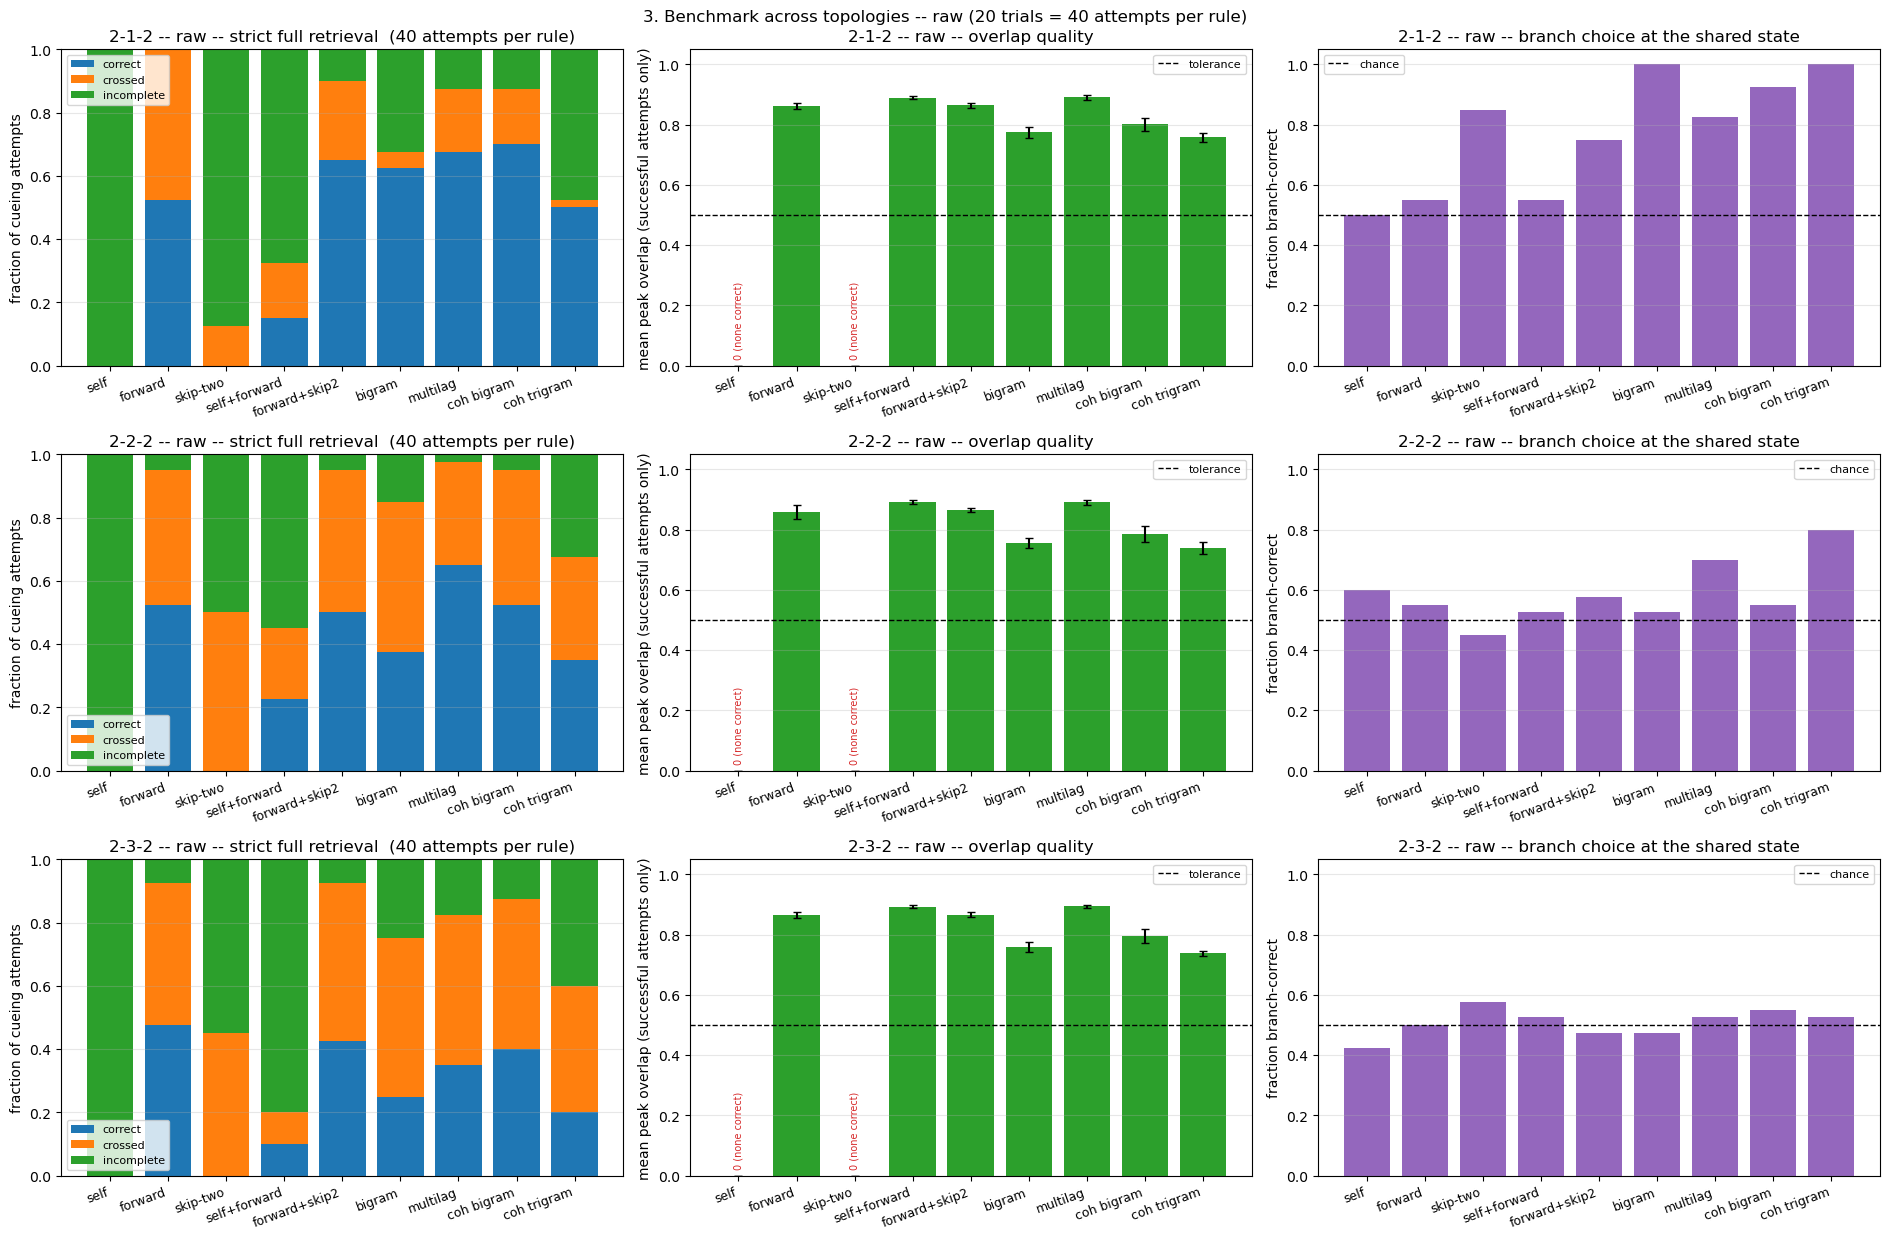

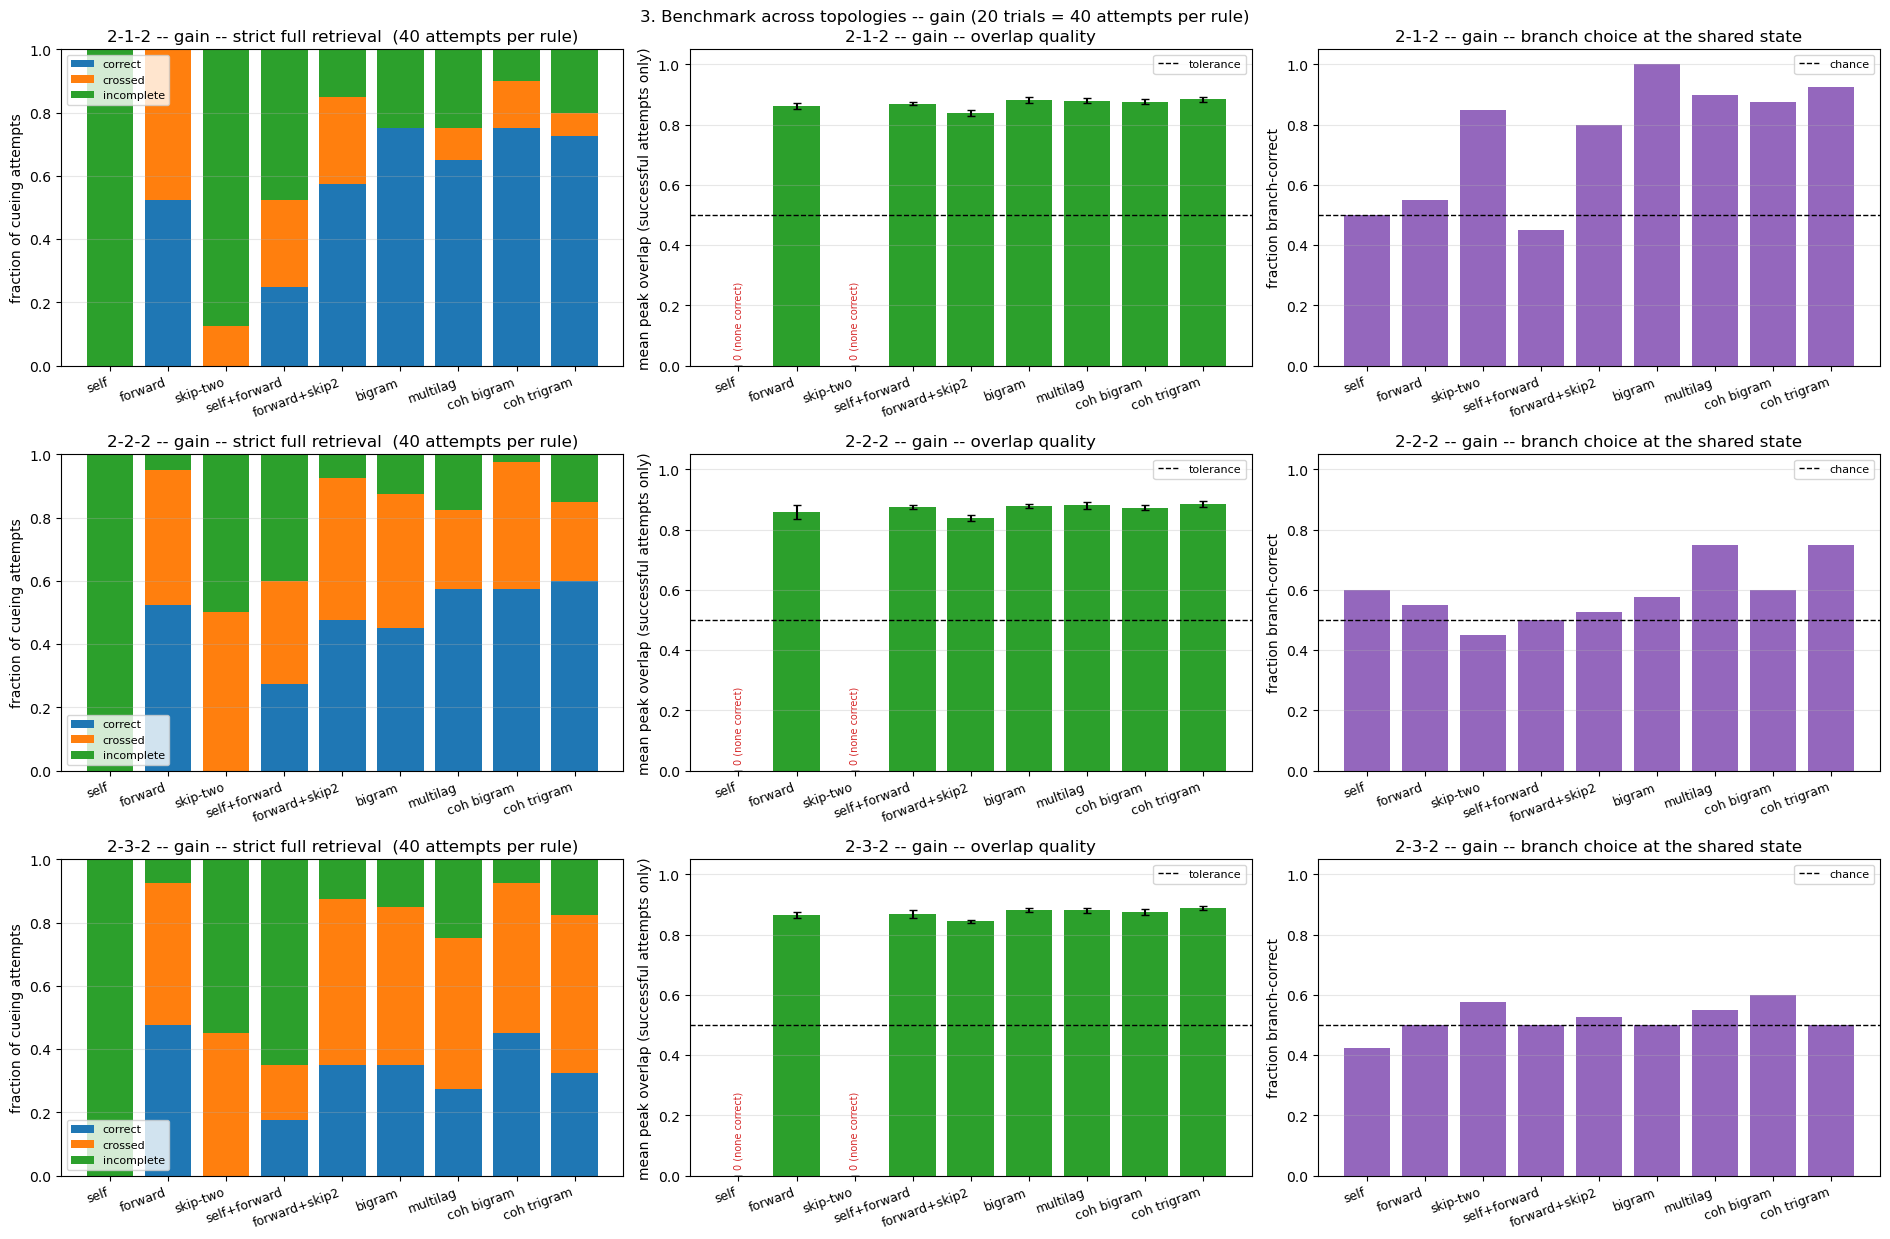

In [11]:
for variant in ("raw", "gain"):
    fig, axes = plt.subplots(len(SPEC), 3, figsize=(19, 4.2 * len(SPEC)))
    for row, tag in enumerate(SPEC):
        plot_rule_stats(bench[(tag, variant)], f"{tag} -- {variant}",
                        axes=np.atleast_2d(axes)[row], show_overlap_var=True)
    fig.suptitle(f"3. Benchmark across topologies -- {variant} "
                 f"({TRIALS} trials = {2 * TRIALS} attempts per rule)")
    plt.tight_layout(); plt.show()

### The decomposition, explicitly

The table below is the argument of the metrics section, checked on this run: `correct` is
predicted by `branch-correct` $\times\ (1 - $`incomplete`$)$. Where the prediction holds, a low
score is *not* a retrieval failure -- it is ambiguity and completion multiplying.

In [12]:
print(f"{'topology':<9}{'rule':<15}{'correct':>9}{'branch':>8}{'incompl':>9}{'predicted':>11}{'err':>7}")
errs = []
for tag in SPEC:
    for rule, s in bench[(tag, "raw")].items():
        if rule in ("self", "skip-two", "self+forward"):
            continue                      # degenerate on this metric -- see §5
        c, a = s["counter"], s["attempts"]
        corr, inc, br = c["correct"] / a, c["incomplete"] / a, s["branch_correct"]
        pred = br * (1 - inc)
        errs.append(abs(pred - corr))
        print(f"{tag:<9}{rule:<15}{corr:>8.0%}{br:>8.0%}{inc:>9.0%}{pred:>11.0%}{pred - corr:>+7.0%}")
print(f"\nmean |error| = {np.mean(errs):.1%}")

topology rule             correct  branch  incompl  predicted    err
2-1-2    forward             52%     55%       0%        55%    +3%
2-1-2    forward+skip2       65%     75%      10%        68%    +3%
2-1-2    bigram              62%    100%      32%        68%    +5%
2-1-2    multilag            68%     82%      12%        72%    +5%
2-1-2    coh bigram          70%     92%      12%        81%   +11%
2-1-2    coh trigram         50%    100%      48%        52%    +3%
2-2-2    forward             52%     55%       5%        52%    -0%
2-2-2    forward+skip2       50%     57%       5%        55%    +5%
2-2-2    bigram              38%     52%      15%        45%    +7%
2-2-2    multilag            65%     70%       2%        68%    +3%
2-2-2    coh bigram          52%     55%       5%        52%    -0%
2-2-2    coh trigram         35%     80%      32%        54%   +19%
2-3-2    forward             48%     50%       8%        46%    -1%
2-3-2    forward+skip2       42%     48%       

## The 100-seed sweep, with statistics

Everything above fixes $\rho = 0.2$. Here a fresh corruption rate is drawn per trial from
$U[0.12, 0.28]$, so each rule faces a *range* of difficulties and the numbers carry a spread
rather than a single operating point. `SEED_TRIALS` instances, identical across rules.

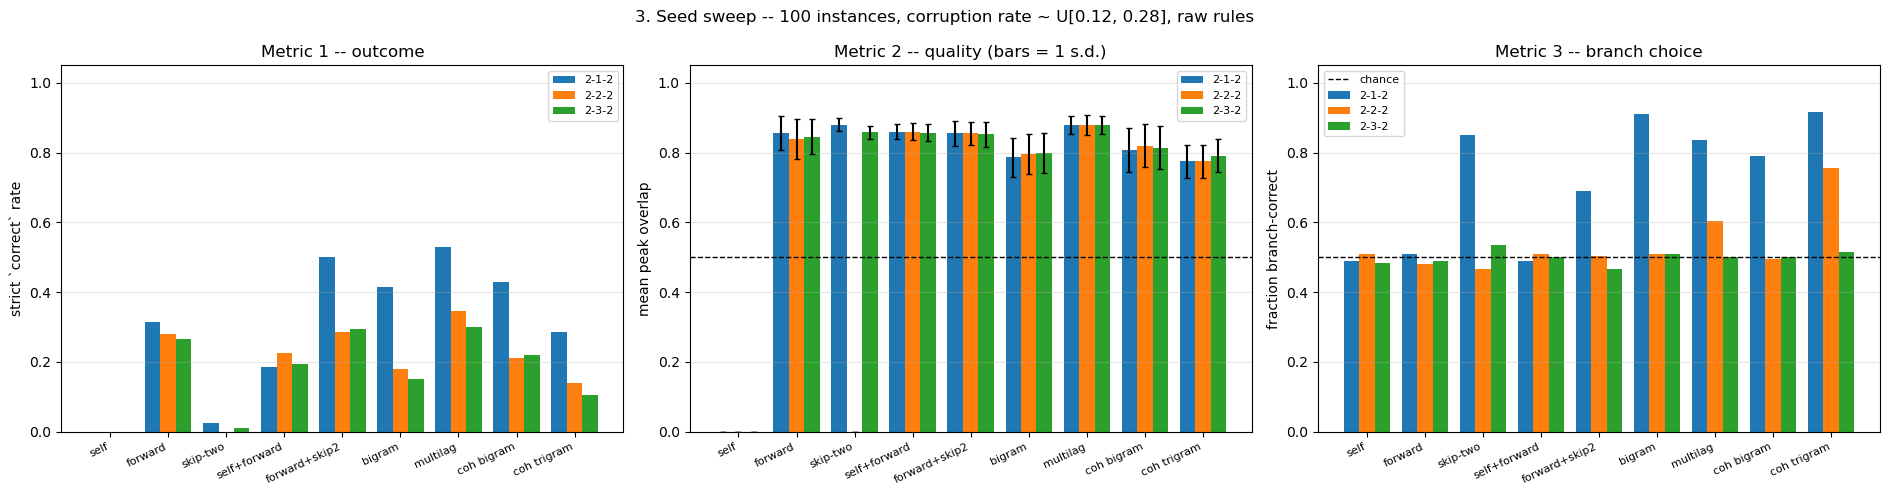

100 seeds, raw. correct% / branch% / overlap +/- s.d.
rule                                  2-1-2                       2-2-2                       2-3-2
self                  0%     49%        n/a       0%     51%        n/a       0%     48%        n/a
forward              32%     51%0.86+/-0.05      28%     48%0.84+/-0.06      26%     49%0.85+/-0.05
skip-two              2%     85%0.88+/-0.02       0%     46%        n/a       1%     54%0.86+/-0.02
self+forward         18%     49%0.86+/-0.02      22%     51%0.86+/-0.02      20%     50%0.86+/-0.02
forward+skip2        50%     69%0.86+/-0.04      28%     50%0.85+/-0.03      30%     46%0.85+/-0.04
bigram               42%     91%0.79+/-0.06      18%     51%0.80+/-0.06      15%     51%0.80+/-0.06
multilag             53%     84%0.88+/-0.03      34%     60%0.88+/-0.03      30%     50%0.88+/-0.03
coh bigram           43%     79%0.81+/-0.06      21%     50%0.82+/-0.06      22%     50%0.81+/-0.06
coh trigram          28%     92%0.77+/-0.05   

In [13]:
_N_KEEP = N
N = N_CROSS          # crossover experiments run at the operating point
def seed_sweep(catalogue, tag, trials=SEED_TRIALS, seed=0):
    sampler = lambda rng: float(rng.uniform(0.12, 0.28))
    stats, _ = rule_sweep(catalogue, **GEOMETRIES[tag], trials=trials, seed=seed,
                          verbose=False, rate_sampler=sampler)
    return stats

seed_stats = {tag: seed_sweep(RAW_CATALOGUE, tag) for tag in SPEC}

fig, axes = plt.subplots(1, 3, figsize=(19, 5.0))
x = np.arange(len(RAW_CATALOGUE)); names = list(RAW_CATALOGUE)
w = 0.8 / len(SPEC)
for k, tag in enumerate(SPEC):
    off = (k - (len(SPEC) - 1) / 2) * w
    st = seed_stats[tag]
    axes[0].bar(x + off, [st[n]["counter"]["correct"] / st[n]["attempts"] for n in names], w, label=tag)
    axes[1].bar(x + off, zeroed([st[n]["mean_overlap"] for n in names]), w, label=tag,
                yerr=zeroed([np.sqrt(st[n]["overlap_var"]) for n in names]), capsize=2)
    axes[2].bar(x + off, [st[n]["branch_correct"] for n in names], w, label=tag)
axes[0].set_ylabel("strict `correct` rate"); axes[0].set_title("Metric 1 -- outcome")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
axes[1].set_ylabel("mean peak overlap"); axes[1].set_title("Metric 2 -- quality (bars = 1 s.d.)")
axes[2].axhline(0.5, color="k", ls="--", lw=1, label="chance")
axes[2].set_ylabel("fraction branch-correct"); axes[2].set_title("Metric 3 -- branch choice")
for ax in axes:
    ax.set_xticks(x, names, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
fig.suptitle(f"3. Seed sweep -- {SEED_TRIALS} instances, corruption rate ~ U[0.12, 0.28], raw rules")
plt.tight_layout(); plt.show()

print(f"{SEED_TRIALS} seeds, raw. correct% / branch% / overlap +/- s.d.")
print(f"{'rule':<15}" + "".join(f"{t:>28}" for t in SPEC))
for n in names:
    row = ""
    for tag in SPEC:
        s = seed_stats[tag][n]; a = s["attempts"]
        q = (f"{s['mean_overlap']:.2f}+/-{np.sqrt(s['overlap_var']):.2f}"
             if s["mean_overlap"] == s["mean_overlap"] else "n/a")
        row += f"{s['counter']['correct'] / a:>9.0%}{s['branch_correct']:>8.0%}{q:>11}"
    print(f"{n:<15}{row}")
N = _N_KEEP


## Branch choice against $N$

Branch choice is the quantity these benchmarks exist to measure, so it gets the same treatment as
retrieval fraction: a spread on every point. It is a proportion over Bernoulli attempts, so the
error bar is the **binomial standard error** $\sqrt{p(1-p)/n}$; `margin`, the continuous quantity
underneath it, carries a genuine s.d.

**Branch choice improves markedly with $N$** -- larger networks decide better. Note the contrast
with metric 1: `incomplete` *rises* with $N$ at fixed duration, because a bigger network needs
longer to traverse. So `correct` understates the gain. **Compare `branch_correct` across $N$, not
`correct`.**

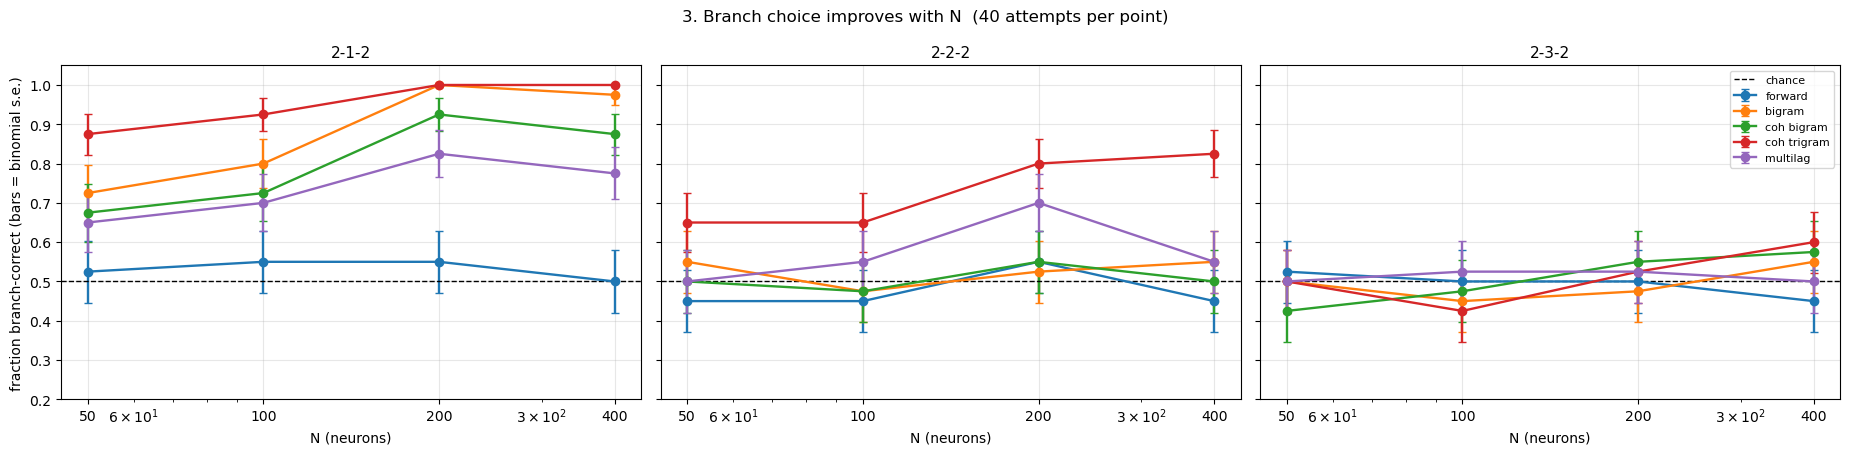

branch-correct +/- binomial s.e.,  and incomplete% for contrast
-- 2-1-2 --
rule          N=50              N=100             N=200             N=400                50->400
forward         52%+/-0.079      55%+/-0.079      55%+/-0.079      50%+/-0.079           -3%
bigram          72%+/-0.071      80%+/-0.063     100%+/-0.000      98%+/-0.025          +25%
coh bigram      68%+/-0.074      72%+/-0.071      92%+/-0.042      88%+/-0.052          +20%
coh trigram     88%+/-0.052      92%+/-0.042     100%+/-0.000     100%+/-0.000          +12%
multilag        65%+/-0.075      70%+/-0.072      82%+/-0.060      78%+/-0.066          +12%
  incomplete  15%                20%                21%                20%                

-- 2-2-2 --
rule          N=50              N=100             N=200             N=400                50->400
forward         45%+/-0.079      45%+/-0.079      55%+/-0.079      45%+/-0.079           +0%
bigram          55%+/-0.079      48%+/-0.079      52%+/-0.079      5

In [14]:
BRANCH_N = [50, 100, 200, 400]
BRANCH_RULES = ["forward", "bigram", "coh bigram", "coh trigram", "multilag"]
BRANCH_CAT = {k: RAW_CATALOGUE[k] for k in BRANCH_RULES}
BRANCH_TRIALS = 20

_N_KEEP = N
branch_vs_n = {}
for tag in SPEC:
    for n in BRANCH_N:
        N = n                                     # rule_sweep reads the module-level N
        branch_vs_n[(tag, n)], _ = rule_sweep(BRANCH_CAT, **GEOMETRIES[tag],
                                              trials=BRANCH_TRIALS, verbose=False)
N = _N_KEEP

fig, axes = plt.subplots(1, len(SPEC), figsize=(6.2 * len(SPEC), 4.6), sharey=True)
for ax, tag in zip(np.atleast_1d(axes), SPEC):
    for rule in BRANCH_RULES:
        ax.errorbar(BRANCH_N,
                    [branch_vs_n[(tag, n)][rule]["branch_correct"] for n in BRANCH_N],
                    yerr=[branch_vs_n[(tag, n)][rule]["branch_se"] for n in BRANCH_N],
                    marker="o", capsize=3, lw=1.7, label=rule)
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_xscale("log"); ax.set_xticks(BRANCH_N, [str(n) for n in BRANCH_N])
    ax.set_xlabel("N (neurons)"); ax.set_title(tag, fontsize=11)
    ax.set_ylim(0.2, 1.05); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("fraction branch-correct (bars = binomial s.e.)")
np.atleast_1d(axes)[-1].legend(fontsize=8)
fig.suptitle(f"3. Branch choice improves with N  ({2 * BRANCH_TRIALS} attempts per point)")
plt.tight_layout(); plt.show()

print(f"branch-correct +/- binomial s.e.,  and incomplete% for contrast")
for tag in SPEC:
    print(f"-- {tag} --")
    print(f"{'rule':<14}" + "".join(f"N={n:<16}" for n in BRANCH_N) + f"{'50->400':>10}")
    for rule in BRANCH_RULES:
        row = "".join(f"{branch_vs_n[(tag, n)][rule]['branch_correct']:>5.0%}"
                      f"+/-{branch_vs_n[(tag, n)][rule]['branch_se']:<9.3f}" for n in BRANCH_N)
        d = (branch_vs_n[(tag, BRANCH_N[-1])][rule]["branch_correct"]
             - branch_vs_n[(tag, BRANCH_N[0])][rule]["branch_correct"])
        print(f"{rule:<14}{row}{d:>+10.0%}")
    print(f"{'  incomplete':<14}" + "".join(
        f"{np.mean([branch_vs_n[(tag, n)][r]['counter']['incomplete'] / branch_vs_n[(tag, n)][r]['attempts'] for r in BRANCH_RULES]):<19.0%}"
        for n in BRANCH_N))
    print()

### Which rule performs better

Read **branch-correct** -- not contaminated by the completion channel.

| rule | reach | verdict |
|---|---|---|
| `coh trigram` | 2 | **best.** Only rule above chance at $L = 2$; also leads at $L = 1$. Pays with the lowest raw drive, which is what `proportional_gain` is for. |
| `coh bigram`, `bigram` | 1 | strong at $L = 1$, **fall to chance at $L = 2$** -- the prediction, cleanly confirmed |
| `multilag` | 1 (×3 lags) | most forgiving; drive redundancy makes it degrade gracefully. Rarely best, almost never worst |
| `forward` | 0 | the control. At chance everywhere, since its gate reads only the shared pattern |

**Nothing clears chance on `2-3-2`** ($L = 3$): every rule reads at most two patterns back, so at
the branch point every gate factor is still inside the shared run.

**Reach $\ge L$ is necessary, not sufficient.** Even with enough reach the discriminating signal
is a dynamic residual surviving $\sim$two steps. Reach is cheap; the information runs out.

---
<a id="4"></a>
# 4. Robustness on a single long chain

No branches: **one smooth chain of $P = 10$**, cued at $\xi^0$, scored by how far it gets.

`self` is the **control** -- no forward drive, so whatever it scores is the artifact floor.
Anything not clearly above it has not been shown to retrieve.

## Reading the single-chain metrics

§3's metrics do not carry over. Two here, named one word apart -- **read the key, not the label**:

| key | question | denominator |
|---|---|---|
| `retrieval_fraction` | how much **of a** sequence came back | per trial `reached / P`, meaned over trials |
| `retrieval_rate` | how many **of the** sequences came back whole | trials scoring exactly 1.0 |

Three traps, all of which produced wrong numbers during this project:

1. **The $1/P$ floor.** Position 0 is the cue and counts, so nothing scores below $10\%$ and a
   rule that does nothing scores exactly that.
2. **Doing the wrong thing scores worse than doing nothing.** The match is a strict prefix, so
   `skip-two` -- correctly implementing $\xi^k \to \xi^{k+2}$ -- decodes `0,2,4,6,8` and breaks at
   step 1. Meanwhile at low $\rho$ `self` climbs *above* the floor: near-duplicate patterns merge
   into one basin and relaxation toward its centroid walks the chain in index order, which a
   prefix metric reads as recall.
3. **"Zero overlap" usually means "no data".** Quality is conditioned on strict full retrieval;
   with no successful trial the mean is undefined and plots as a literal `0.0`. A rule can show
   zero overlap and non-zero retrieval with no contradiction.

The cell below demonstrates 1 and 2 by printing decoded index paths.

In [15]:
DEMO_METRIC_RULES = ["self", "skip-two", "forward"]

print("Decoded index paths -- what each rule actually reports back")
print("(ground truth is 0,1,2,...,9;  P = %d, so the floor is %.2f)\n" % (SEQ_LEN + 1, 1 / (SEQ_LEN + 1)))
for rho in (0.05, CONFIG["corruption_rate"]):
    print(f"-- rho = {rho:.2f} --")
    for rule in DEMO_METRIC_RULES:
        net = kc.ContextNetwork(rule=RAW_CATALOGUE[rule], N=N, seed=10,
                                **{**CONFIG, "corruption_rate": rho})
        rng, fr, paths = np.random.default_rng(0), [], []
        for t in range(8):
            seq = krm.generate_sequence(N, SEQ_LEN, rho, name="A", seed=int(rng.integers(SEED_POOL)))
            res = net.simulate(seq, T=DWELL_PER_TRANSITION * SEQ_LEN)
            dec = net.decode_sequence_online(res, seq, margin=SEQ_MARGIN)
            fr.append(net.compare_to_stored_sequence(dec, seq) / len(seq))
            if t < 3:
                paths.append("".join(str(i) for _, i in dec)[:12])
        print(f"   {rule:<9} fraction = {np.mean(fr):.2f}   decoded: {paths}")
    print()

print("Read: at rho=0.05 `self` (no forward drive at all) beats `skip-two` (a working rule),")
print("because centroid relaxation walks the chain in order while a correct skip breaks the prefix.")

Decoded index paths -- what each rule actually reports back
(ground truth is 0,1,2,...,9;  P = 10, so the floor is 0.10)

-- rho = 0.05 --
   self      fraction = 0.49   decoded: ['01234', '01234', '01234']
   skip-two  fraction = 0.31   decoded: ['012456789', '02346789', '01247898989']
   forward   fraction = 0.66   decoded: ['012345678', '01234567', '0124']

-- rho = 0.20 --
   self      fraction = 0.10   decoded: ['0', '0', '0']
   skip-two  fraction = 0.10   decoded: ['024689', '024689', '02356789']
   forward   fraction = 0.94   decoded: ['012346789', '0123456789', '0123456789']

Read: at rho=0.05 `self` (no forward drive at all) beats `skip-two` (a working rule),
because centroid relaxation walks the chain in order while a correct skip breaks the prefix.


## 4a. Does retrieval get better or worse with $N$?

**It gets better -- and an earlier version of this project concluded the opposite.**

The regular Krotov DAM improves with $N$: capacity $\sim N^{\,d-1}$, overlaps concentrate as
$1/\sqrt{N}$. The context rules were previously measured as doing the **reverse**, recorded as an
artifact peculiar to them. **That does not reproduce.** Sweeping $N$ at fixed $\rho$, retrieval
improves monotonically for every rule in **both** frequency regimes:

| $\Delta$ retrieval fraction, $N: 100 \to 400$ | $\sigma_\omega = 0.3$ | const $\omega = 0.05$ |
|---|---|---|
| `bigram` | **+0.21** | **+0.14** |
| `coh trigram` | +0.09 | **+0.24** |
| `coh bigram` | +0.11 | +0.06 |
| `multilag` | +0.05 | +0.12 |
| `forward` | +0.04 | +0.00 (already 1.00) |
| `self` (control) | −0.01 | +0.00 |

**What changed was integration time.** The original ran at `DWELL_PER_TRANSITION = 6.0`
($T = 54$); this notebook uses 20.0 ($T = 180$). At $T = 54$ the large-$N$ runs had not finished,
and an unfinished cascade scores as a short retrieval -- indistinguishable from degradation.

No $N$ anomaly: these rules behave like the dense memory they are built on. The surviving lesson
is methodological -- **a duration validated at one $N$ is not validated at another** (§5c).

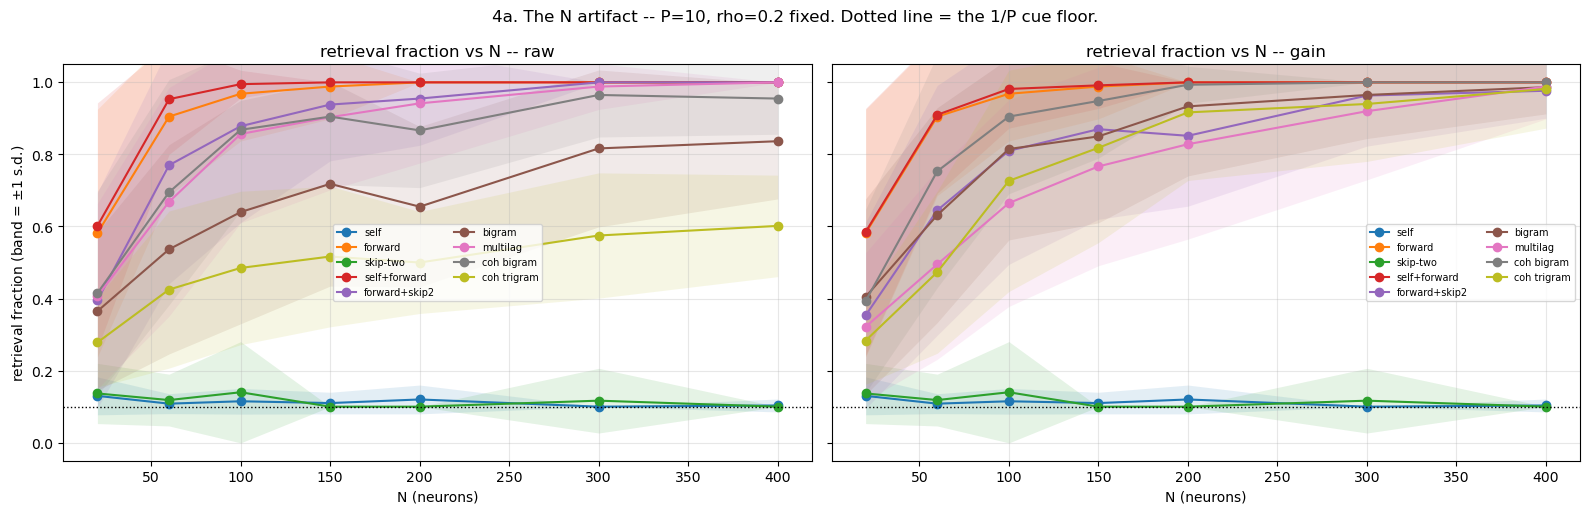

-- raw: retrieval fraction +/- s.d. --
rule           N=20           N=60           N=100          N=150          N=200          N=300          N=400          
self           0.13+/-0.05 0.11+/-0.03 0.11+/-0.04 0.11+/-0.03 0.12+/-0.04 0.10+/-0.00 0.10+/-0.02 
forward        0.58+/-0.34 0.90+/-0.22 0.97+/-0.13 0.99+/-0.09 1.00+/-0.00 1.00+/-0.00 1.00+/-0.00 
skip-two       0.14+/-0.08 0.12+/-0.07 0.14+/-0.14 0.10+/-0.00 0.10+/-0.00 0.12+/-0.09 0.10+/-0.00 
self+forward   0.60+/-0.34 0.95+/-0.15 0.99+/-0.04 1.00+/-0.00 1.00+/-0.00 1.00+/-0.00 1.00+/-0.00 
forward+skip2  0.39+/-0.30 0.77+/-0.33 0.88+/-0.27 0.94+/-0.16 0.95+/-0.13 1.00+/-0.00 1.00+/-0.00 
bigram         0.36+/-0.22 0.54+/-0.29 0.64+/-0.31 0.72+/-0.28 0.65+/-0.22 0.82+/-0.22 0.84+/-0.16 
multilag       0.41+/-0.26 0.67+/-0.32 0.86+/-0.25 0.90+/-0.20 0.94+/-0.17 0.99+/-0.06 1.00+/-0.00 
coh bigram     0.41+/-0.28 0.69+/-0.31 0.87+/-0.22 0.90+/-0.19 0.87+/-0.16 0.96+/-0.12 0.95+/-0.10 
coh trigram    0.28+/-0.12 0.42+/-0.22 0

In [16]:
N_SWEEP = [20, 60, 100, 150, 200, 300, 400]
n_sweep = {variant: {n: single_sequence_score_sweep(cat, seq_len=SEQ_LEN,
                                                    corruption_rate=CONFIG["corruption_rate"],
                                                    N=n, trials=SINGLE_SEQ_TRIALS)
                     for n in N_SWEEP}
           for variant, cat in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), sharey=True)
for ax, variant in zip(axes, ("raw", "gain")):
    for name in RAW_CATALOGUE:
        band(ax, N_SWEEP, [n_sweep[variant][n][name]["retrieval_fraction"] for n in N_SWEEP],
             [n_sweep[variant][n][name]["fraction_std"] for n in N_SWEEP], label=name)
    ax.axhline(0.1, color="k", ls=":", lw=1)
    ax.set_xlabel("N (neurons)"); ax.set_title(f"retrieval fraction vs N -- {variant}")
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
axes[0].set_ylabel("retrieval fraction (band = $\\pm$1 s.d.)")
fig.suptitle(f"4a. The N artifact -- P={SEQ_LEN + 1}, rho={CONFIG['corruption_rate']} fixed. "
             f"Dotted line = the 1/P cue floor.")
plt.tight_layout(); plt.show()

for variant in ("raw", "gain"):
    print(f"-- {variant}: retrieval fraction +/- s.d. --")
    print(f"{'rule':<15}" + "".join(f"N={n:<13}" for n in N_SWEEP))
    for name in RAW_CATALOGUE:
        print(f"{name:<15}" + "".join(
            f"{n_sweep[variant][n][name]['retrieval_fraction']:.2f}+/-{n_sweep[variant][n][name]['fraction_std']:.2f} "
            for n in N_SWEEP))
    print()

/var/folders/h1/1sk3l_wn59l0gcj89qp1l5tw0000gn/T/ipykernel_82063/3451422751.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  line, = ax.plot(x, means, "-o", **kw)


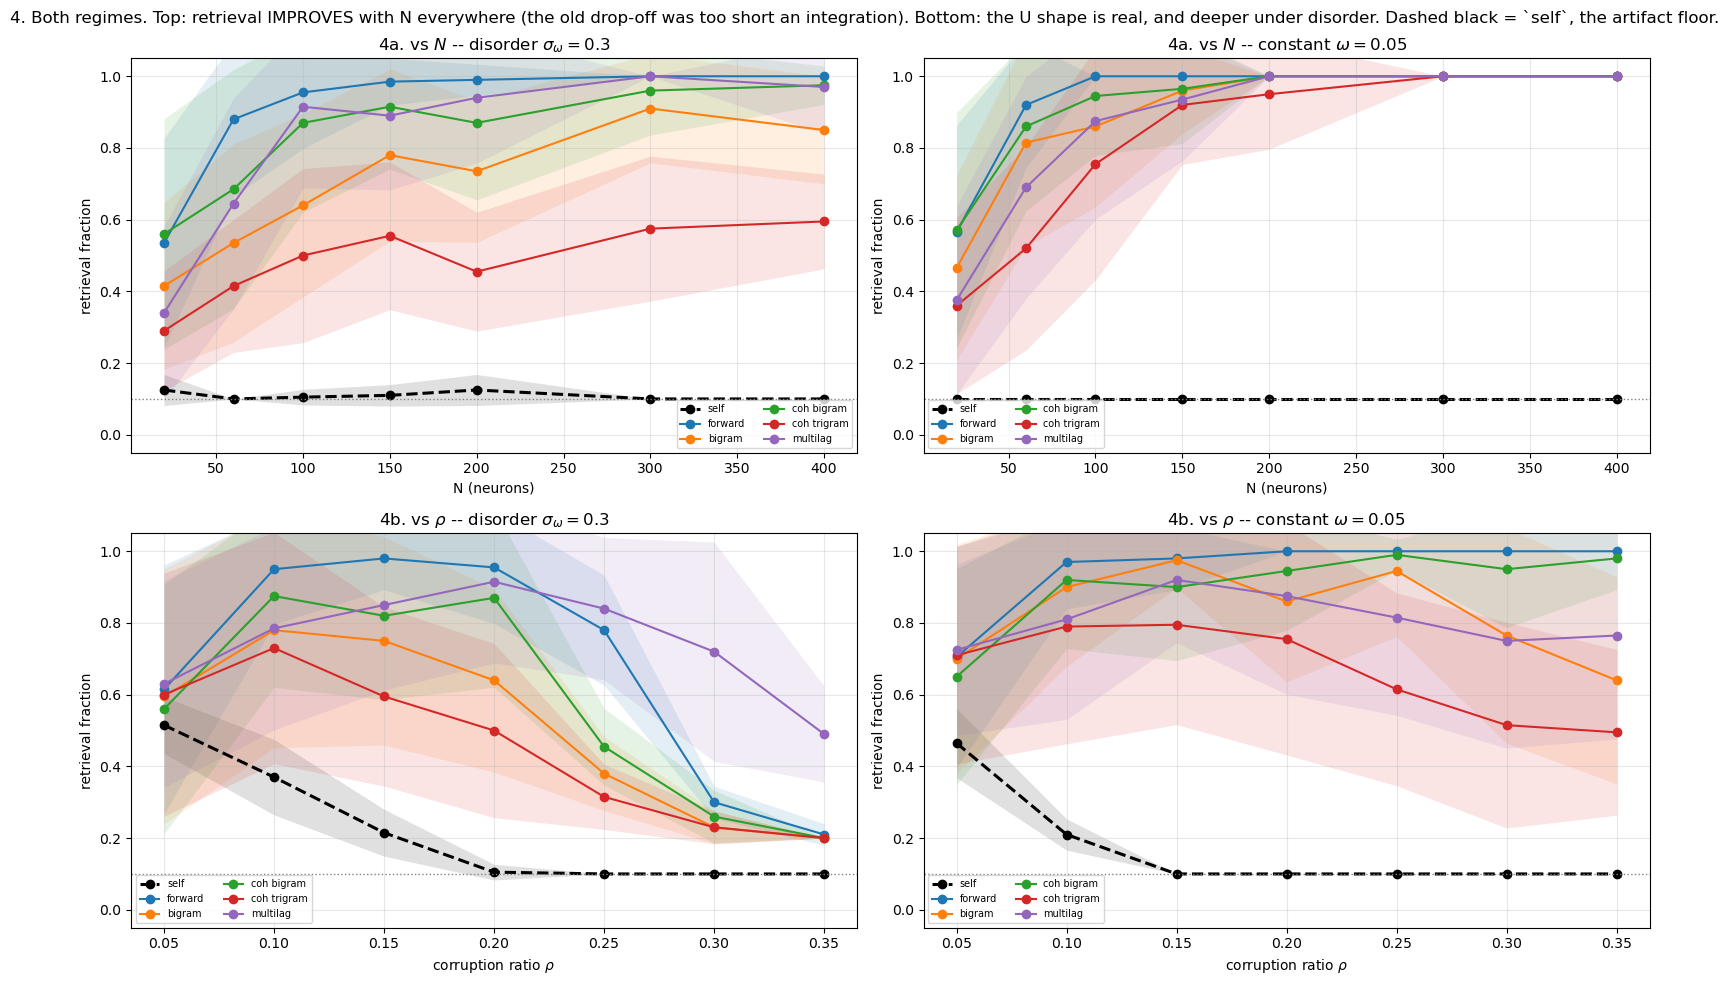

In [17]:
# Both frequency regimes on the same axes, so the 4a retraction and the 4b U shape are
# visible rather than asserted. `self` is plotted throughout as the artifact floor.
REGIMES = [("disorder $\\sigma_\\omega=0.3$", {"frequency_mean": 0.0, "frequency_std": 0.3}),
           ("constant $\\omega=0.05$",        {"frequency_mean": 0.05, "frequency_std": 0.0})]
CMP_RULES = ["self", "forward", "bigram", "coh bigram", "coh trigram", "multilag"]
CMP_CAT = {k: RAW_CATALOGUE[k] for k in CMP_RULES}
CMP_TRIALS = 20
CMP_N   = [20, 60, 100, 150, 200, 300, 400]
CMP_RHO = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for col, (label, ov) in enumerate(REGIMES):
    nres = {n: single_sequence_score_sweep(CMP_CAT, seq_len=SEQ_LEN, corruption_rate=0.2, N=n,
                                           trials=CMP_TRIALS, config_overrides=ov) for n in CMP_N}
    rres = {r: single_sequence_score_sweep(CMP_CAT, seq_len=SEQ_LEN, corruption_rate=r, N=N,
                                           trials=CMP_TRIALS, config_overrides=ov) for r in CMP_RHO}
    for rule in CMP_RULES:
        st = dict(lw=2.2, ls="--", color="k") if rule == "self" else {}
        band(axes[0, col], CMP_N, [nres[n][rule]["retrieval_fraction"] for n in CMP_N],
             [nres[n][rule]["fraction_std"] for n in CMP_N], label=rule, **st)
        band(axes[1, col], CMP_RHO, [rres[r][rule]["retrieval_fraction"] for r in CMP_RHO],
             [rres[r][rule]["fraction_std"] for r in CMP_RHO], label=rule, **st)
    axes[0, col].set_xlabel("N (neurons)"); axes[0, col].set_title(f"4a. vs $N$ -- {label}")
    axes[1, col].set_xlabel(r"corruption ratio $\rho$"); axes[1, col].set_title(f"4b. vs $\\rho$ -- {label}")
for ax in axes.ravel():
    ax.axhline(1 / (SEQ_LEN + 1), color="grey", ls=":", lw=1)
    ax.set_ylabel("retrieval fraction"); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
fig.suptitle("4. Both regimes. Top: retrieval IMPROVES with N everywhere (the old drop-off was "
             "too short an integration). Bottom: the U shape is real, and deeper under disorder. "
             "Dashed black = `self`, the artifact floor.")
plt.tight_layout(); plt.show()

## 4b. The U shape across corruption ratios

This one **holds**, in both regimes. Sweeping $\rho$ (consecutive-pattern overlap $= 1 - 2\rho$)
gives an **interior peak** at $\rho \approx 0.10$–$0.25$ with failure at both ends: near-duplicate
patterns the decoder cannot separate at low $\rho$, patterns too far to bridge at high $\rho$.

**The low end inflates, it does not only depress.** `self` peaks at the *edge*, $\rho = 0.05$,
scoring $\sim$0.5 against its 0.10 floor -- pure artifact, since it has no forward drive.

**The high end is regime-dependent.** Under disorder it collapses to the floor ($\rho = 0.35$:
`forward` 0.21, `bigram` 0.20); at constant $\omega$ it barely falls (`forward` 1.00, `coh
bigram` 0.98). So the right-hand failure is mostly the **spread** of $\omega$, not pattern
distance -- consistent with §1. The U is much shallower without disorder.

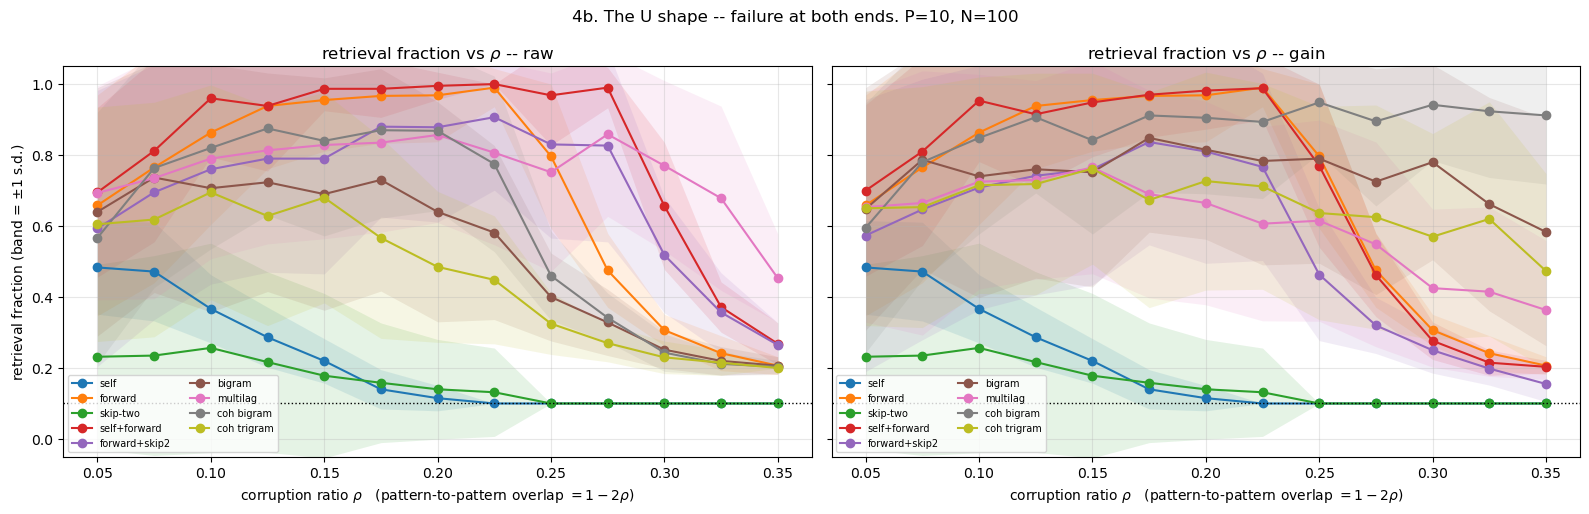

the `self` control -- no forward drive, so this row IS the artifact floor
rho     0.05    0.07    0.10    0.12    0.15    0.17    0.20    0.22    0.25    0.27    0.30    0.32    0.35    
self    0.48    0.47    0.37    0.29    0.22    0.14    0.11    0.10    0.10    0.10    0.10    0.10    0.10    


In [18]:
RHO_SWEEP = np.linspace(0.05, 0.35, 13)
rho_res = {}
for variant in ("raw", "gain"):
    rho_res[variant] = {}
    for rho in RHO_SWEEP:
        cat = (RAW_CATALOGUE if variant == "raw" else
               {n: kc.proportional_gain(r, rho) for n, r in RAW_CATALOGUE.items()})
        rho_res[variant][rho] = single_sequence_score_sweep(
            cat, seq_len=SEQ_LEN, corruption_rate=rho, N=N, trials=SINGLE_SEQ_TRIALS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), sharey=True)
for ax, variant in zip(axes, ("raw", "gain")):
    for name in RAW_CATALOGUE:
        band(ax, RHO_SWEEP, [rho_res[variant][r][name]["retrieval_fraction"] for r in RHO_SWEEP],
             [rho_res[variant][r][name]["fraction_std"] for r in RHO_SWEEP], label=name)
    ax.axhline(0.1, color="k", ls=":", lw=1)
    ax.set_xlabel(r"corruption ratio $\rho$   (pattern-to-pattern overlap $= 1-2\rho$)")
    ax.set_title(f"retrieval fraction vs $\\rho$ -- {variant}")
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
axes[0].set_ylabel("retrieval fraction (band = $\\pm$1 s.d.)")
fig.suptitle(f"4b. The U shape -- failure at both ends. P={SEQ_LEN + 1}, N={N}")
plt.tight_layout(); plt.show()

print("the `self` control -- no forward drive, so this row IS the artifact floor")
print(f"{'rho':<8}" + "".join(f"{r:<8.2f}" for r in RHO_SWEEP))
print(f"{'self':<8}" + "".join(f"{rho_res['raw'][r]['self']['retrieval_fraction']:<8.2f}" for r in RHO_SWEEP))

## 4c. Two knobs worth knowing

§4a's artifact was integration time, so neither of these is a *repair* for it. Both remain useful
controls on the drive.

**(i) `proportional_gain`** -- hold $\omega$, raise the drive. Divides each term by
$(1-2\rho)^{\sum\text{lags}}$, removing the handicap on a lag-heavy gate whose product of
sub-unit factors is small *before* it sees a branch. **Not uniformly good**: §3 shows it harmful
on the easiest geometry (amplifying a sufficient drive destabilises it) and a no-op on
single-row zero-lag rules.

**(ii) Move $\omega$** -- hold the drive, change the frequency. §1 gives the shape.

The grid sweeps $N$ and $\sigma_\omega$ **independently** -- the control that separates a genuine
scaling law (*tilted contour*) from a pure $\omega$ effect (*flat columns*). Read the columns
before believing any exponent $p$ in $\omega(N) = \omega_0 (N_0/N)^p$: a one-dimensional scan
along such a law looks like confirmation even when $\omega$ alone is the knob.

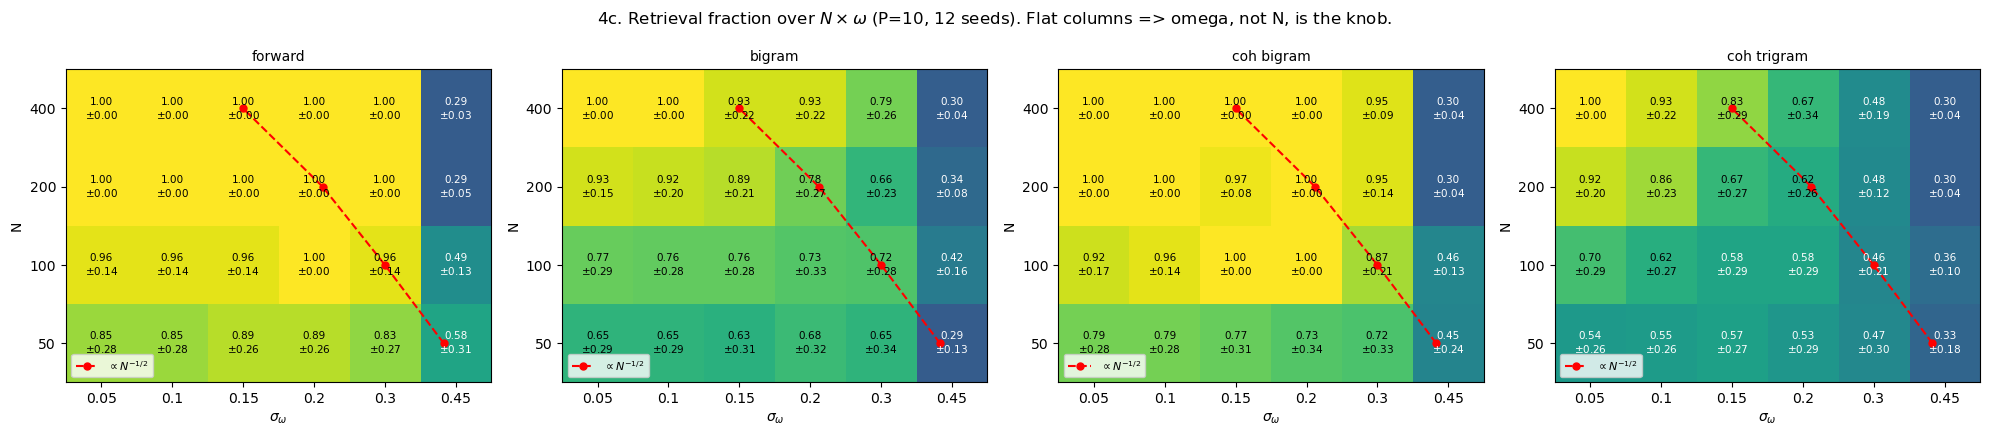

In [19]:
W_GRID_N = [50, 100, 200, 400]
W_GRID_W = [0.05, 0.1, 0.15, 0.2, 0.3, 0.45]
W_GRID_RULES = ["forward", "bigram", "coh bigram", "coh trigram"]
W_GRID_TRIALS = 12

def frac_at(rule, n, w, trials=W_GRID_TRIALS):
    r = single_sequence_score_sweep({rule: RAW_CATALOGUE[rule]}, seq_len=SEQ_LEN,
                                    corruption_rate=CONFIG["corruption_rate"], N=n, trials=trials,
                                    config_overrides={"frequency_mean": 0.0, "frequency_std": w})
    return r[rule]["retrieval_fraction"], r[rule]["fraction_std"]

grids = {r: [[frac_at(r, n, w) for w in W_GRID_W] for n in W_GRID_N] for r in W_GRID_RULES}

fig, axes = plt.subplots(1, len(W_GRID_RULES), figsize=(5.0 * len(W_GRID_RULES), 4.4))
for ax, rule in zip(np.atleast_1d(axes), W_GRID_RULES):
    gm = np.array([[m for m, _ in row] for row in grids[rule]])
    gs = np.array([[s for _, s in row] for row in grids[rule]])
    ax.imshow(gm, cmap="viridis", vmin=0, vmax=1, origin="lower", aspect="auto")
    for i in range(len(W_GRID_N)):
        for j in range(len(W_GRID_W)):
            ax.text(j, i, f"{gm[i, j]:.2f}\n$\\pm${gs[i, j]:.2f}", ha="center", va="center",
                    fontsize=7.5, color="w" if gm[i, j] < 0.6 else "k")
    xs = [np.interp(0.3 * (100 / n) ** 0.5, W_GRID_W, range(len(W_GRID_W))) for n in W_GRID_N]
    ax.plot(xs, range(len(W_GRID_N)), "r--o", lw=1.5, ms=5, label=r"$\propto N^{-1/2}$")
    ax.set_xticks(range(len(W_GRID_W)), [f"{w:g}" for w in W_GRID_W])
    ax.set_yticks(range(len(W_GRID_N)), [str(n) for n in W_GRID_N])
    ax.set_xlabel(r"$\sigma_\omega$"); ax.set_ylabel("N"); ax.set_title(rule, fontsize=10)
    ax.legend(fontsize=8, loc="lower left")
fig.suptitle(f"4c. Retrieval fraction over $N \\times \\omega$ "
             f"(P={SEQ_LEN + 1}, {W_GRID_TRIALS} seeds). Flat columns => omega, not N, is the knob.")
plt.tight_layout(); plt.show()

---
<a id="5"></a>
# 5. Appendix

## 5a. Random (uncorrelated) patterns

Every chain above is a **mutation chain**: consecutive patterns overlap $1 - 2\rho$. That
similarity is what lets the drive bridge one pattern to the next.

With **independently random** patterns retrieval disappears. Strict rates are 0% everywhere, so
the informative quantity is *how far off* -- the highest overlap reached on any non-cue pattern,
over all trials. It sits far below `tolerance`.

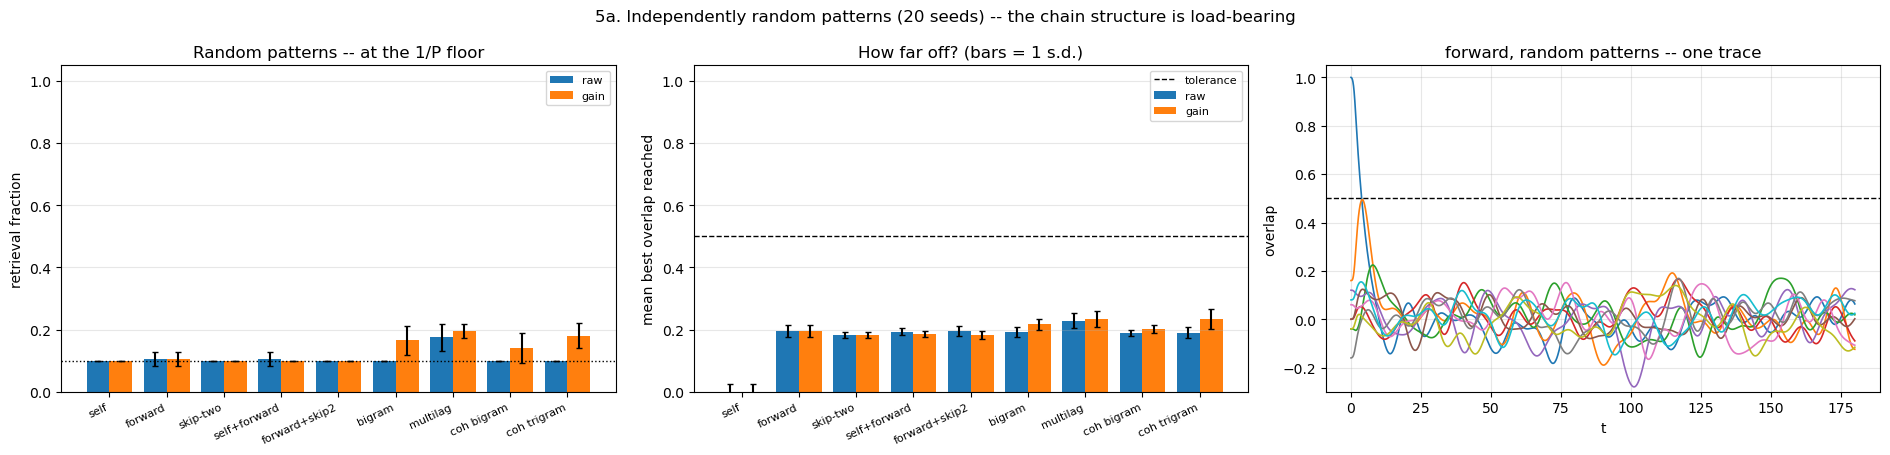

rule               raw frac    raw peak   gain frac   gain peak
self                    10%       -0.01         10%       -0.01
forward                 11%        0.20         11%        0.20
skip-two                10%        0.18         10%        0.18
self+forward            11%        0.19         10%        0.19
forward+skip2           10%        0.20         10%        0.18
bigram                  10%        0.19         17%        0.22
multilag                18%        0.23         20%        0.23
coh bigram              10%        0.19         14%        0.20
coh trigram             10%        0.19         18%        0.23


In [20]:
RANDOM_TRIALS = 20

rand = {v: single_sequence_score_sweep(cat, seq_len=SEQ_LEN,
                                       corruption_rate=CONFIG["corruption_rate"], N=N,
                                       trials=RANDOM_TRIALS, random_patterns=True)
        for v, cat in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))}

def best_reached(catalogue, trials=RANDOM_TRIALS, seed=0):
    rng, out = np.random.default_rng(seed), {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **CONFIG)
        vals = []
        for _ in range(trials):
            seq = generate_random_sequence(N, SEQ_LEN, name="A", seed=int(rng.integers(SEED_POOL)))
            r = net.simulate(seq, T=DWELL_PER_TRANSITION * SEQ_LEN)
            vals.append(float(r["overlaps"][:, 1:].max(axis=0).mean()))
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out

reached = {v: best_reached(c) for v, c in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))}

names = list(RAW_CATALOGUE); x = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(19, 4.6))
for off, v in ((-0.2, "raw"), (0.2, "gain")):
    axes[0].bar(x + off, [rand[v][n]["retrieval_fraction"] for n in names], 0.4, label=v,
                yerr=[rand[v][n]["fraction_std"] for n in names], capsize=2)
    axes[1].bar(x + off, [reached[v][n][0] for n in names], 0.4, label=v,
                yerr=[reached[v][n][1] for n in names], capsize=2)
axes[0].axhline(0.1, color="k", ls=":", lw=1)
axes[0].set_ylabel("retrieval fraction"); axes[0].set_title("Random patterns -- at the 1/P floor")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean best overlap reached"); axes[1].set_title("How far off? (bars = 1 s.d.)")
for ax in axes[:2]:
    ax.set_xticks(x, names, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# a stalling trace: nothing ever clears tolerance
net = kc.ContextNetwork(rule=RAW_CATALOGUE["forward"], N=N, seed=10, **CONFIG)
rseq = generate_random_sequence(N, SEQ_LEN, name="A", seed=11)
rr = net.simulate(rseq, T=DWELL_PER_TRANSITION * SEQ_LEN)
for k in range(len(rseq)):
    axes[2].plot(rr["time"], rr["overlaps"][:, k], lw=1.2)
axes[2].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
axes[2].set_title("forward, random patterns -- one trace"); axes[2].set_xlabel("t")
axes[2].set_ylabel("overlap"); axes[2].set_ylim(-0.3, 1.05); axes[2].grid(alpha=0.3)
fig.suptitle(f"5a. Independently random patterns ({RANDOM_TRIALS} seeds) -- the chain structure is load-bearing")
plt.tight_layout(); plt.show()

print(f"{'rule':<15}{'raw frac':>12}{'raw peak':>12}{'gain frac':>12}{'gain peak':>12}")
for n in names:
    print(f"{n:<15}{rand['raw'][n]['retrieval_fraction']:>12.0%}{reached['raw'][n][0]:>12.2f}"
          f"{rand['gain'][n]['retrieval_fraction']:>12.0%}{reached['gain'][n][0]:>12.2f}")

## 5b. `boundary="self"` vs `"cycle"`

What the network does at the **end** of a stored sequence. `"self"` lets the last pattern be
its own successor, so the trajectory settles there; `"cycle"` wires the last pattern back to
the first, so it should loop indefinitely.

**`"cycle"` does not work.** Settling is not incidental to retrieval here -- it is what makes
each pattern a usable attractor long enough to be decoded. Wiring the tail back to the head
removes the terminal fixed point and the trajectory degrades rather than looping.

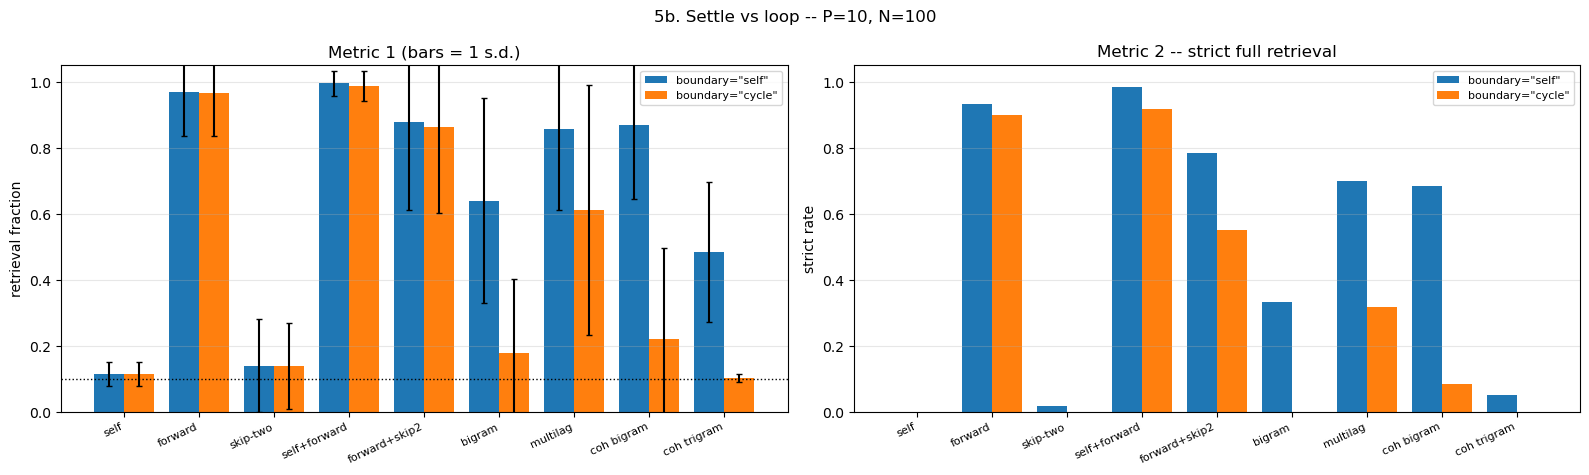

rule              self frac  self strict   cycle frac  cycle strict
self                   0.11           0%         0.11            0%
forward                0.97          93%         0.97           90%
skip-two               0.14           2%         0.14            0%
self+forward           0.99          98%         0.99           92%
forward+skip2          0.88          78%         0.86           55%
bigram                 0.64          33%         0.18            0%
multilag               0.86          70%         0.61           32%
coh bigram             0.87          68%         0.22            8%
coh trigram            0.49           5%         0.10            0%


In [21]:
boundary_res = {}
for boundary in ("self", "cycle"):
    boundary_res[boundary] = single_sequence_score_sweep(
        RAW_CATALOGUE, seq_len=SEQ_LEN, corruption_rate=CONFIG["corruption_rate"], N=N,
        trials=SINGLE_SEQ_TRIALS, boundary=boundary)

names = list(RAW_CATALOGUE); x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for off, b in ((-0.2, "self"), (0.2, "cycle")):
    axes[0].bar(x + off, [boundary_res[b][n]["retrieval_fraction"] for n in names], 0.4,
                yerr=[boundary_res[b][n]["fraction_std"] for n in names], capsize=2,
                label=f'boundary="{b}"')
    axes[1].bar(x + off, [boundary_res[b][n]["retrieval_rate"] for n in names], 0.4,
                label=f'boundary="{b}"')
axes[0].axhline(0.1, color="k", ls=":", lw=1)
axes[0].set_ylabel("retrieval fraction"); axes[0].set_title("Metric 1 (bars = 1 s.d.)")
axes[1].set_ylabel("strict rate"); axes[1].set_title("Metric 2 -- strict full retrieval")
for ax in axes:
    ax.set_xticks(x, names, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
fig.suptitle(f"5b. Settle vs loop -- P={SEQ_LEN + 1}, N={N}")
plt.tight_layout(); plt.show()

print(f"{'rule':<15}{'self frac':>12}{'self strict':>13}{'cycle frac':>13}{'cycle strict':>14}")
for n in names:
    s, c = boundary_res["self"][n], boundary_res["cycle"][n]
    print(f"{n:<15}{s['retrieval_fraction']:>12.2f}{s['retrieval_rate']:>13.0%}"
          f"{c['retrieval_fraction']:>13.2f}{c['retrieval_rate']:>14.0%}")

## 5c. Is it the clock? Integration time is not a free parameter

The integrator carries a **stationary early-stop** and returns once the drift settles, so
outcomes are invariant over a wide range of $T$ and generous durations are nearly free.

Two consequences:

- **`incomplete` is not a duration problem.** It sounds like "needed longer"; it is not.
  Lengthening 5$\times$ leaves those outcomes unchanged, because the trajectory has *settled* at
  a sub-tolerance fixed point. Only a change to the drive -- gain, rule, $N$ -- moves it.
- **But too *short* a duration fabricates findings.** §4a's retracted artifact was exactly this.
  A trajectory that has not finished is indistinguishable, under every metric here, from one that
  failed.

The exception is the bottom of the $\omega$ range (§1): below $\omega \approx 0.01$ the escape
genuinely is slow and duration does matter.

In [22]:
DUR_CHECK = [DWELL_PER_TRANSITION * SEQ_LEN, 300.0, 600.0]
DUR_RULES = ["forward", "bigram", "coh bigram", "coh trigram", "multilag"]
DUR_TRIALS = 20

print("Long chain -- strict rate / fraction vs integration time")
print(f"{'rule':<14}" + "".join(f"T={d:<16g}" for d in DUR_CHECK))
for rule in DUR_RULES:
    row = ""
    for d in DUR_CHECK:
        r = single_sequence_score_sweep({rule: RAW_CATALOGUE[rule]}, seq_len=SEQ_LEN,
                                        corruption_rate=CONFIG["corruption_rate"], N=N,
                                        trials=DUR_TRIALS, duration=d)[rule]
        row += f"{r['retrieval_rate']:>3.0%} / {r['retrieval_fraction']:.2f}       "
    print(f"{rule:<14}{row}")

print("\nHow early does it actually stop? (steps integrated vs steps scheduled)")
net = kc.ContextNetwork(rule=RAW_CATALOGUE["forward"], N=N, seed=10, **CONFIG)
seq = krm.generate_sequence(N, SEQ_LEN, CONFIG["corruption_rate"], name="A", seed=1234)
for d in DUR_CHECK:
    res = net.simulate(seq, T=d)
    print(f"   T={d:<6g} integrated {res['theta_history'].shape[0]:>5} of "
          f"{int(d / CONFIG['dt']) + 1:>5} steps"
          f"   ({res['theta_history'].shape[0] / (int(d / CONFIG['dt']) + 1):.0%})")

Long chain -- strict rate / fraction vs integration time
rule          T=180             T=300             T=600             
forward       95% / 0.97       95% / 0.97       95% / 0.97       
bigram        45% / 0.70       45% / 0.70       45% / 0.70       
coh bigram    75% / 0.88       75% / 0.88       75% / 0.88       
coh trigram    5% / 0.45        5% / 0.45        5% / 0.45       
multilag      65% / 0.84       65% / 0.84       65% / 0.84       

How early does it actually stop? (steps integrated vs steps scheduled)
   T=180    integrated   739 of  3601 steps   (21%)
   T=300    integrated   739 of  6001 steps   (12%)
   T=600    integrated   739 of 12001 steps   (6%)


---

# Summary

1. **A natural frequency is structurally necessary.** At an exact cue $\sin\theta_i = 0$, so
   $\omega \equiv 0$ is an exact fixed point -- not a slow limit. The drive is anchored to the
   $\{0,\pi\}$ lattice, so $\omega$ is a real parameter, not a gauge choice. Usable band
   $\approx [0.02, 0.2]$; a ceiling, not a peak.
2. **Branching needs a gate reaching past the shared run.** Inside a run of length $L$ the current
   pattern is identical between branches, so a gate reading only it is at chance. Reach $\ge L$ is
   **necessary but not sufficient** -- the discriminating signal is a residual surviving $\sim$two
   steps, and nothing in the catalogue clears $L = 3$.
3. **`coh trigram` wins on branch choice**, the only rule above chance at $L = 2$;
   `bigram`/`coh bigram` hold at $L = 1$ and fall to chance at $L = 2$, exactly as reach predicts;
   `multilag` is most robust; `forward` is at chance everywhere.
4. **Branch choice improves markedly with $N$** -- the effect is on the *decision*, not the
   cascade. Under a fixed duration cap `incomplete` rises at the same time, so `correct`
   understates it: compare `branch_correct` across $N$, not `correct`.
5. **A low `correct` is two failures multiplying**:
   $\text{correct} \approx \text{branch-correct} \times (1 - \text{incomplete})$. The
   `incomplete` half is **not** a duration problem (§5c).
6. **Retrieval improves with $N$, like the dense memory it is built on.** The earlier finding
   that these rules *degrade* with $N$ **does not reproduce** in either regime -- it was an
   integration-time artifact (§4a).
7. **Retrieval is non-monotone in $\rho$, and that one is real.** Interior peak, failure at both
   ends; the high-$\rho$ collapse is mostly the *spread* of $\omega$ and nearly vanishes at
   constant $\omega$; the low-$\rho$ end **inflates** scores (§4b).

## Caveats

- **$n = 1$ on the $\omega$ axis.** Every network uses `seed=10`, so one $\omega$ draw is reused
  across every trial, rule and geometry. Spreads are over patterns and corruption rate, never over
  disorder realisations. Resampling $\omega$ per trial is the highest-value next addition.
- **The $1/P$ floor.** `retrieval_fraction` counts the cue, so nothing scores below $10\%$ at
  $P = 10$, and a rule that transitions *wrongly* scores below one that does not transition at
  all. `self` and `skip-two` are controls for this, never results.
- **`1-1-1` flatters `skip-two`**, which jumps $\xi^0 \to \xi^2$ over the shared pattern and never
  faces the ambiguity being tested.
- **Integration time is not a free parameter** -- the easiest way to manufacture a false finding
  here, and the one that produced the retracted §4a. Generous durations are nearly free (§5c).